In [1]:
import pandas as pd
import numpy as np
import os
import sklearn
import scipy 
import re
import matplotlib.pyplot as plt

from functools import reduce

import logging
logging.disable(logging.ERROR) 
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 10})

plt.rcParams["legend.frameon"] = False

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


In [2]:
%cd /home/varshini/uc_analyses/
# import compartment_calling
import utils
import compartments
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
# is it best to do this processing on the fly?
def load_eigs(eig_paths, eigdirs, cov, phases):    
    eigs_phase = []
    
    for i, phase in enumerate(phases):
        curr_eig = compartments.get_possumm_eig(eig_paths[i], eigdirs[i], cov, 2000, cov_value_col='GC')
        eigs_phase.append(curr_eig.rename(columns={c: c+f'_P{i+1}' for c in curr_eig.columns[3:]}))

    eigs_phase_merged = reduce(lambda left,right: pd.merge(left,right,on=['chrom', 'start','end'], 
                                                    how='outer'), eigs_phase)
    
    return eigs_phase_merged

# window_elt = size of the window in coordinate space, not kb 
def get_sub_eig(row, eig_chrom, phases=['P1', 'P2', 'P3'], window_kb=200, res_kb=2):

    coord = row.start
    locus_start = (coord-window_kb*1000)//(res_kb*1000)
    locus_end = (coord+window_kb*1000)//(res_kb*1000)
    
    locus = eig_chrom.iloc[locus_start:locus_end, :]
    
    # computeMatrix is written in python... so i'm gonna assume that it's python indexing... the source code seems to do it this way
    arr = locus[[f'E1_{p}' for p in phases]].to_numpy()
    
    if np.shape(arr)[0] < (window_kb // res_kb)*2:
        
        #print(f"insufficient length for region {coord}")
        arr = np.pad(arr, ((0, ((window_kb // res_kb)*2)-np.shape(arr)[0]), (0,0)), constant_values=np.nan)
        #print(np.shape(arr))
    return arr

def locus_eigs(regions, eig_df, phases=['P1','P2','P3'],
               window_kb=200, res_kb=2):

    n_bins = (window_kb // res_kb) * 2
    eigs_loci = np.zeros((len(regions), n_bins, len(phases)))

    eig_by_chrom = {
        chrom: df.reset_index(drop=True)
        for chrom, df in eig_df.groupby("chrom", sort=False)
    }

    for i, reg in regions.iterrows():
        eig_chrom = eig_by_chrom.get(reg.chr)
        if eig_chrom is None:
            continue
        eigs_loci[i, :, :] = get_sub_eig(
            reg, eig_chrom, phases, window_kb, res_kb
        )

    return eigs_loci

def get_match_labels(matchbed_path):
    ## TODO make it a flexible number of columns for the non-perturbation
    matchmaker_labels = pd.read_csv(matchbed_path, sep="\t", names=['chr','start','end','val','perturbation'])
    
    #matchmaker_labels = utils.clean_chroms(matchmaker_labels)

    matchmaker_labels["locus"] = matchmaker_labels.apply(lambda row: f"{row['chr']}:{(row['start']+row['end'])//2}", 
                                                         axis=1)
    match_dedup = matchmaker_labels.drop_duplicates(subset="locus").sort_values(by=['chr','start','end']).reset_index(drop=True)
    
    
    return matchmaker_labels, match_dedup

def load_process_bw(matchbed_path, track_path, matchscores):
    matchmaker_labels, match_dedup = get_match_labels(matchbed_path)
    match_dedup = match_dedup[match_dedup["locus"].isin(matchscores.index)].reset_index(drop=True)
    
    tracks = pd.read_csv(track_path, sep="\t", skiprows=2, index_col=0)
    print(len(tracks))
    # assumes the tracks and the matchmaker labels are the same regions exactly. i.e. matchbed_path was the input to 
    # the computeMatrix command that made the file in track_path

    tracks.set_index(matchmaker_labels['locus'], inplace=True)
    
    assert (tracks[~tracks.index.duplicated(keep='first')].equals(tracks.drop_duplicates()))

    tracks_dup = tracks.drop_duplicates()
   
    tracks_dup = tracks_dup.reindex(match_dedup["locus"])
    tracks_dup = tracks_dup[tracks_dup.index.isin(matchscores.index)]
    
    
    return tracks_dup, matchmaker_labels, match_dedup


def load_matchmaker_scores_phase(basedir, phases, nametag, dist=100000):
    match_scores_list = []
    for i, phase in enumerate(phases): 
        curr = pd.read_csv(os.path.join(basedir, f"{phase}_{nametag}_loopscores_{dist}_withpeaks.tsv"), sep='\t', index_col=0)
        match_scores_list.append(curr.rename(columns={c: c+f'_P{i+1}' for c in curr.columns[3:]}))

        match_scores = reduce(lambda left,right: pd.merge(left,right,on=['chr', 'coord','perturbation_name'], how='outer'), match_scores_list)
        match_scores["locus"] = match_scores.apply(lambda row: f"{row['chr']}:{int(row['coord'])}", 
                                                             axis=1)

        match_scores_dedup = match_scores.drop_duplicates(subset=['chr','coord'])
        match_scores_dedup.set_index("locus", inplace=True)

    return match_scores_dedup


# center = track_stack.shape[2] // 2
# indices = np.abs(np.arange(track_stack.shape[2]) - center)

# split the track into distance regimes and integrate the signal over these
# bins are input one-sided relative to the center 
# option to input in kb or in pixel? if in kb, then have to indicate how big the whole window was 
def make_distance_bins(track_stack, bin_locs, bin_type='kb',
                       res_kb=2, how='sum'):

    if bin_type == 'kb':
        bins = bin_locs // res_kb
    else:
        bins = bin_locs

    L = track_stack.shape[2]
    center = L // 2
    distances = np.abs(np.arange(L) - center)

    bin_indices = np.digitize(distances, bins)
    print(bin_indices)
    print(distances)
    binned_data = np.zeros(
        (track_stack.shape[0], track_stack.shape[1], len(bins))
    )

    for i in range(0, len(bins)):
        mask = bin_indices == i
        
        if how == 'sum':
            binned_data[:, :, i] = track_stack[:, :, mask].sum(axis=2)
        elif how == 'mean':
            binned_data[:, :, i] = track_stack[:, :, mask].mean(axis=2)
    return binned_data
        
# docs from np
#     x = np.array([1.2, 10.0, 12.4, 15.5, 20.])
# bins = np.array([0, 5, 10, 15, 20])
# np.digitize(x,bins,right=True)
# array([1, 2, 3, 4, 4])
# np.digitize(x,bins,right=False)
# array([1, 3, 3, 4, 5])
    

bin_indices[distances > bins[-1]] = -1

    binned_data = np.zeros(
        (track_stack.shape[0], track_stack.shape[1], len(bins))
    )

    for i in range(len(bins)):
        mask = bin_indices == i
        if how == 'sum':
            binned_data[:, :, i] = track_stack[:, :, mask].sum(axis=2)
        elif how == 'mean':
            binned_data[:, :, i] = track_stack[:, :, mask].mean(axis=2)

    return binned_data

In [58]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v3/fig3"
if not os.path.exists(savedir):
    os.mkdir(savedir)
    
supp_savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v3/supp7"
if not os.path.exists(supp_savedir):
    os.mkdir(supp_savedir)

In [5]:
resolution = 2000

In [6]:
# inputs 
inputs_bw ='/mnt/md0/varshini/Analysis/Blood/matchmakers/model_input_tables/erythroid_tf_acrs_all_enhancernotpromoternotctcf_complete_v2.tab'
match_dir = "/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/classifications/erythroid_tf_acrs_all_enhancernotpromoternotctcf.bed"


In [7]:
os.listdir('/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/')

['032524_combined_DAP_JAN_028_ATAC.bed',
 'classifications_uniqueE',
 'erythroid_associated_ACRs.bed',
 'erythroid_tf_acrs_all.bed',
 'acrs_unique.bed',
 'ATAC_not_CTCF.bed',
 'erythroid_tf_acrs_unique.bed',
 'tf_acrs_sorted.bed',
 'classifications']

In [8]:
analysis_path = '/mnt/md0/varshini/Analysis/Blood/Merged_Compartments'
eig_path = "/mnt/florence_md0/varshini/cooler_dumps"
phases_eig = ['P1', 'P2', 'P3']


eigdirs = [os.path.join(eig_path, f"res_{resolution//1000}kb", phase) 
           for phase in phases_eig] 
possumm_eig_paths = [os.path.join(analysis_path, f"{phase}_compartments_possumm_{resolution//1000}kb_gc.tsv") 
                     for phase in phases_eig]
cov = pd.read_csv(os.path.join(analysis_path, "Phase3_dedup_hg38_gc_cov_100kb.tsv"), sep="\t")

In [9]:
eigs = load_eigs(possumm_eig_paths, eigdirs, cov, phases_eig)
#eig_mat = process_mat(eigs)
# make the eigs by phase for each matchmaker in the same format as the inputs 
# so, n_matchmaker x n_phases (3) x len_vector (200)

In [10]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/matchmaker_scores'
phases = ['Phase1_', 'Phase2_dedup',  'Phase3_dedup']

type_use= 'erythroid_tf_acrs_all'
peak_use = 'enhancernotpromoternotctcf'


In [11]:
match_scores = load_matchmaker_scores_phase(datapath, phases, nametag = f"{type_use}_{peak_use}", dist=100000)

In [12]:
tracks_bw, match_labels, match_labels_dedup = load_process_bw(match_dir, inputs_bw, match_scores)


15108


In [13]:
tracks_bw

,P1_H3K27ac,P1_H3K27ac.1,P1_H3K27ac.2,P1_H3K27ac.3,P1_H3K27ac.4,P1_H3K27ac.5,P1_H3K27ac.6,P1_H3K27ac.7,P1_H3K27ac.8,P1_H3K27ac.9,...,Phase2_ATAC.190,Phase2_ATAC.191,Phase2_ATAC.192,Phase2_ATAC.193,Phase2_ATAC.194,Phase2_ATAC.195,Phase2_ATAC.196,Phase2_ATAC.197,Phase2_ATAC.198,Phase2_ATAC.199
locus,,,,,,,,,,,,,,,,,,,,,
chr1:1024327,1.2250,0.0500,0.150,0.1000,0.050,0.0000,0.0500,0.3000,0.1635,0.3365,...,53.740,41.580,25.290,35.340,36.710,25.290,25.960,31.000,27.330,NaN
chr1:1715437,0.6250,0.0500,0.150,0.1435,0.075,0.1315,0.4000,0.1685,0.4815,0.8685,...,37.180,22.880,25.250,16.920,83.150,249.000,61.500,30.400,35.830,NaN
chr1:1728757,0.2500,0.5000,0.750,0.9500,0.350,1.1820,1.9030,1.0650,1.1530,1.0360,...,42.450,31.450,40.750,60.730,434.700,54.570,39.180,32.840,24.580,NaN
chr1:2199415,0.4075,0.1425,0.100,0.0000,0.250,0.0500,0.2500,0.2000,0.3000,0.1500,...,109.000,28.460,26.320,24.130,116.600,343.100,31.500,17.850,17.000,NaN
chr1:2278258,0.0790,0.2750,0.246,0.1580,0.342,0.2000,0.3500,0.1500,0.1500,0.3040,...,23.210,18.320,22.950,39.360,31.160,25.760,25.180,29.550,25.230,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:154484721,0.0000,0.0000,0.000,0.0000,0.250,0.2105,0.1395,0.2500,0.2105,1.1900,...,4.856,4.734,8.228,11.230,10.130,12.020,9.532,6.260,7.962,NaN
chrX:154495704,0.2480,0.1770,0.173,0.9310,0.721,0.7250,0.6480,0.3000,0.2500,0.2520,...,10.440,7.730,8.502,4.939,7.059,6.024,4.446,6.851,8.159,NaN
chrX:154799311,0.1500,0.1000,0.100,0.1000,0.000,0.0500,0.0000,0.0000,0.0000,0.0000,...,6.030,8.151,7.009,9.099,6.717,6.707,5.460,8.684,13.130,NaN


In [14]:
features = (
    tracks_bw.columns
      .str.replace(r"\.\d+$", "", regex=True)
      .unique()
      .tolist()
)

In [15]:
features

['P1_H3K27ac',
 'P1_H3K4me1',
 'P2_CTCF',
 'P1_CTCF',
 'Phase1_RNA_chr',
 'P3_H3K27ac',
 'P3_CTCF',
 'Phase1_ATAC',
 'Phase2_RNA_chr',
 'Phase3_ATAC',
 'Phase3_RNA_chr',
 'P2_H3K27ac',
 'P2_H3K4me1',
 'Phase2_ATAC']

In [16]:
feat_keep = features

pattern = re.compile(rf"^({'|'.join(feat_keep)})(\.\d+)?$")
tracks_bw = tracks_bw.loc[:, tracks_bw.columns.str.match(pattern)]

In [17]:
tracks_bw

,P1_H3K27ac,P1_H3K27ac.1,P1_H3K27ac.2,P1_H3K27ac.3,P1_H3K27ac.4,P1_H3K27ac.5,P1_H3K27ac.6,P1_H3K27ac.7,P1_H3K27ac.8,P1_H3K27ac.9,...,Phase2_ATAC.190,Phase2_ATAC.191,Phase2_ATAC.192,Phase2_ATAC.193,Phase2_ATAC.194,Phase2_ATAC.195,Phase2_ATAC.196,Phase2_ATAC.197,Phase2_ATAC.198,Phase2_ATAC.199
locus,,,,,,,,,,,,,,,,,,,,,
chr1:1024327,1.2250,0.0500,0.150,0.1000,0.050,0.0000,0.0500,0.3000,0.1635,0.3365,...,53.740,41.580,25.290,35.340,36.710,25.290,25.960,31.000,27.330,NaN
chr1:1715437,0.6250,0.0500,0.150,0.1435,0.075,0.1315,0.4000,0.1685,0.4815,0.8685,...,37.180,22.880,25.250,16.920,83.150,249.000,61.500,30.400,35.830,NaN
chr1:1728757,0.2500,0.5000,0.750,0.9500,0.350,1.1820,1.9030,1.0650,1.1530,1.0360,...,42.450,31.450,40.750,60.730,434.700,54.570,39.180,32.840,24.580,NaN
chr1:2199415,0.4075,0.1425,0.100,0.0000,0.250,0.0500,0.2500,0.2000,0.3000,0.1500,...,109.000,28.460,26.320,24.130,116.600,343.100,31.500,17.850,17.000,NaN
chr1:2278258,0.0790,0.2750,0.246,0.1580,0.342,0.2000,0.3500,0.1500,0.1500,0.3040,...,23.210,18.320,22.950,39.360,31.160,25.760,25.180,29.550,25.230,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:154484721,0.0000,0.0000,0.000,0.0000,0.250,0.2105,0.1395,0.2500,0.2105,1.1900,...,4.856,4.734,8.228,11.230,10.130,12.020,9.532,6.260,7.962,NaN
chrX:154495704,0.2480,0.1770,0.173,0.9310,0.721,0.7250,0.6480,0.3000,0.2500,0.2520,...,10.440,7.730,8.502,4.939,7.059,6.024,4.446,6.851,8.159,NaN
chrX:154799311,0.1500,0.1000,0.100,0.1000,0.000,0.0500,0.0000,0.0000,0.0000,0.0000,...,6.030,8.151,7.009,9.099,6.717,6.707,5.460,8.684,13.130,NaN


In [18]:
features = (
    tracks_bw.columns
      .str.replace(r"\.\d+$", "", regex=True)
      .unique()
      .tolist()
)
features.extend(['E1_P1','E1_P2','E1_P3'])

In [19]:
tracks_bw

,P1_H3K27ac,P1_H3K27ac.1,P1_H3K27ac.2,P1_H3K27ac.3,P1_H3K27ac.4,P1_H3K27ac.5,P1_H3K27ac.6,P1_H3K27ac.7,P1_H3K27ac.8,P1_H3K27ac.9,...,Phase2_ATAC.190,Phase2_ATAC.191,Phase2_ATAC.192,Phase2_ATAC.193,Phase2_ATAC.194,Phase2_ATAC.195,Phase2_ATAC.196,Phase2_ATAC.197,Phase2_ATAC.198,Phase2_ATAC.199
locus,,,,,,,,,,,,,,,,,,,,,
chr1:1024327,1.2250,0.0500,0.150,0.1000,0.050,0.0000,0.0500,0.3000,0.1635,0.3365,...,53.740,41.580,25.290,35.340,36.710,25.290,25.960,31.000,27.330,NaN
chr1:1715437,0.6250,0.0500,0.150,0.1435,0.075,0.1315,0.4000,0.1685,0.4815,0.8685,...,37.180,22.880,25.250,16.920,83.150,249.000,61.500,30.400,35.830,NaN
chr1:1728757,0.2500,0.5000,0.750,0.9500,0.350,1.1820,1.9030,1.0650,1.1530,1.0360,...,42.450,31.450,40.750,60.730,434.700,54.570,39.180,32.840,24.580,NaN
chr1:2199415,0.4075,0.1425,0.100,0.0000,0.250,0.0500,0.2500,0.2000,0.3000,0.1500,...,109.000,28.460,26.320,24.130,116.600,343.100,31.500,17.850,17.000,NaN
chr1:2278258,0.0790,0.2750,0.246,0.1580,0.342,0.2000,0.3500,0.1500,0.1500,0.3040,...,23.210,18.320,22.950,39.360,31.160,25.760,25.180,29.550,25.230,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:154484721,0.0000,0.0000,0.000,0.0000,0.250,0.2105,0.1395,0.2500,0.2105,1.1900,...,4.856,4.734,8.228,11.230,10.130,12.020,9.532,6.260,7.962,NaN
chrX:154495704,0.2480,0.1770,0.173,0.9310,0.721,0.7250,0.6480,0.3000,0.2500,0.2520,...,10.440,7.730,8.502,4.939,7.059,6.024,4.446,6.851,8.159,NaN
chrX:154799311,0.1500,0.1000,0.100,0.1000,0.000,0.0500,0.0000,0.0000,0.0000,0.0000,...,6.030,8.151,7.009,9.099,6.717,6.707,5.460,8.684,13.130,NaN


In [20]:
# now reshape the track matrix to be nxpx200
track_mat = tracks_bw.to_numpy()
track_stack = track_mat.reshape(np.shape(track_mat)[0], np.shape(track_mat)[1]//200, 200)

In [21]:
np.shape(track_stack)

(4194, 14, 200)

In [22]:
features

['P1_H3K27ac',
 'P1_H3K4me1',
 'P2_CTCF',
 'P1_CTCF',
 'Phase1_RNA_chr',
 'P3_H3K27ac',
 'P3_CTCF',
 'Phase1_ATAC',
 'Phase2_RNA_chr',
 'Phase3_ATAC',
 'Phase3_RNA_chr',
 'P2_H3K27ac',
 'P2_H3K4me1',
 'Phase2_ATAC',
 'E1_P1',
 'E1_P2',
 'E1_P3']

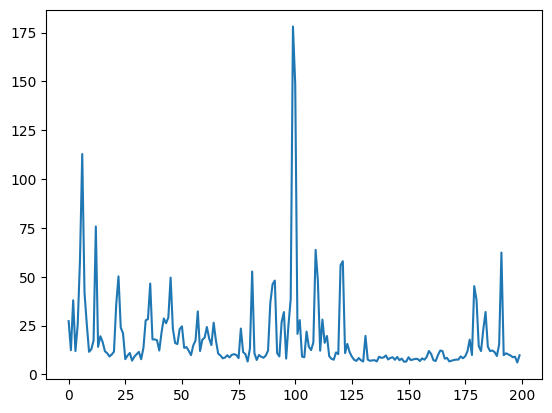

In [23]:
plt.plot(track_stack[100, 12, :])

In [24]:
out = locus_eigs(match_labels_dedup.reset_index(drop=True), eigs)
out_T = np.transpose(out, (0, 2, 1))

In [25]:
# now min-max scale along features 

def standardize_per_feature(X, eps=1e-8):
    X[np.isnan(X)] = 0
    mean = X.mean(axis=(0, 2), keepdims=True)
    #mmax = np.percentile(X, 98, axis=(0, 2), keepdims=True)
    #print(mmax)
    std  = X.std(axis=(0, 2), keepdims=True)
    return (X - mean) / (std + eps)
    
    #return X / mmax

def max_norm(X, eps=1e-8):
    X[np.isnan(X)] = 0
    #mean = X.mean(axis=(0, 2), keepdims=True)
    #mmax = np.percentile(X, 98, axis=(0, 2), keepdims=True)   
    mmax = np.max(X, axis=(0,2), keepdims=True)
    print(mmax)
    return X / mmax

def min_norm(X, eps=1e-8):
    X[np.isnan(X)] = 0
    #mean = X.mean(axis=(0, 2), keepdims=True)
    #mmax = np.percentile(X, 98, axis=(0, 2), keepdims=True)   
    mmin = np.percentile(X, 2, axis=(0, 2), keepdims=True)  
    return X - mmin

def mean_norm(X, eps=1e-8):
    X[np.isnan(X)] = 0
    mean = X.mean(axis=(0, 2), keepdims=True)
    #mmax = np.percentile(X, 98, axis=(0, 2), keepdims=True)
    #print(mmax)
    std  = X.std(axis=(0, 2), keepdims=True)
    return (X - mean) 

def log_norm(X, eps=1):
    X[np.isnan(X)] = 0
    #mean = X.mean(axis=(0, 2), keepdims=True)
    #mmax = np.percentile(X, 98, axis=(0, 2), keepdims=True)   
    lognorm = np.log10(X+eps)

    return lognorm
    
inputs_logged = log_norm(track_stack)
std_logged = standardize_per_feature(inputs_logged)
inputs_maxed = standardize_per_feature(out_T)

inputs_std[1, 0, :]

In [26]:
#all_inputs = np.concatenate([track_stack, out_T], axis=1)
inputs_std = np.concatenate([inputs_logged, inputs_maxed], axis=1)

In [27]:
np.shape(inputs_std)

(4194, 17, 200)

In [28]:
features

['P1_H3K27ac',
 'P1_H3K4me1',
 'P2_CTCF',
 'P1_CTCF',
 'Phase1_RNA_chr',
 'P3_H3K27ac',
 'P3_CTCF',
 'Phase1_ATAC',
 'Phase2_RNA_chr',
 'Phase3_ATAC',
 'Phase3_RNA_chr',
 'P2_H3K27ac',
 'P2_H3K4me1',
 'Phase2_ATAC',
 'E1_P1',
 'E1_P2',
 'E1_P3']

In [29]:
output = match_scores['triangle_score_P3'].values
output[np.isnan(output)] = 0
output[output==np.inf] = 0

In [30]:
bin_arr = np.arange(10, 110, 10)
binned_inputs = make_distance_bins(inputs_std, bin_arr, how='mean')
binned_inputs[np.isnan(binned_inputs)] = 0
binned_0 = binned_inputs.reshape(binned_inputs.shape[0], -1)


[10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10  9  9  9  9  9  8  8  8  8  8  7  7  7  7  7  6  6  6  6  6  5
  5  5  5  5  4  4  4  4  4  3  3  3  3  3  2  2  2  2  2  1  1  1  1  1
  0  0  0  0  0  0  0  0  0  1  1  1  1  1  2  2  2  2  2  3  3  3  3  3
  4  4  4  4  4  5  5  5  5  5  6  6  6  6  6  7  7  7  7  7  8  8  8  8
  8  9  9  9  9  9 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10]
[100  99  98  97  96  95  94  93  92  91  90  89  88  87  86  85  84  83
  82  81  80  79  78  77  76  75  74  73  72  71  70  69  68  67  66  65
  64  63  62  61  60  59  58  57  56  55  54  53  52  51  50  49  48  47
  46  45  44  43  42  41  40  39  38  37  36  35  34  33  32  31  30  29
  28  27  26  25  24  23  22  21  20  19  18  17  16  15  14  13  12  11
  10   9   8   7   6   5 

In [31]:
num_bins = len(bin_arr)
num_features =len(features)

In [32]:
scaled_data = binned_0.copy()
for f in range(num_features):
    cols = slice(f*num_bins, (f+1)*num_bins)
    scaled_data[:, cols] = StandardScaler().fit_transform(scaled_data[:, cols])

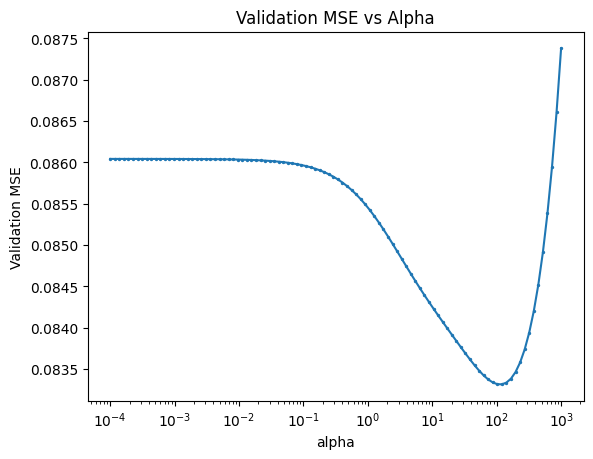

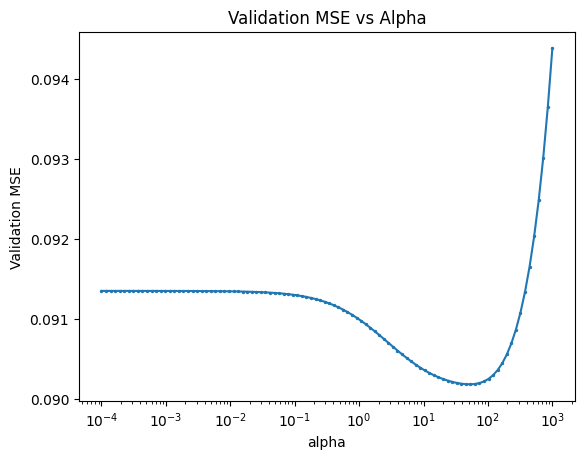

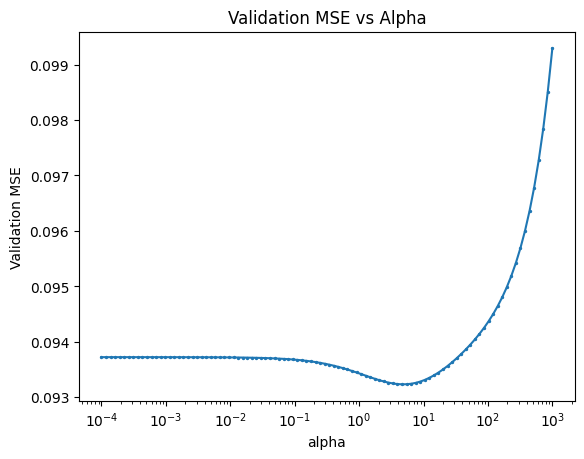

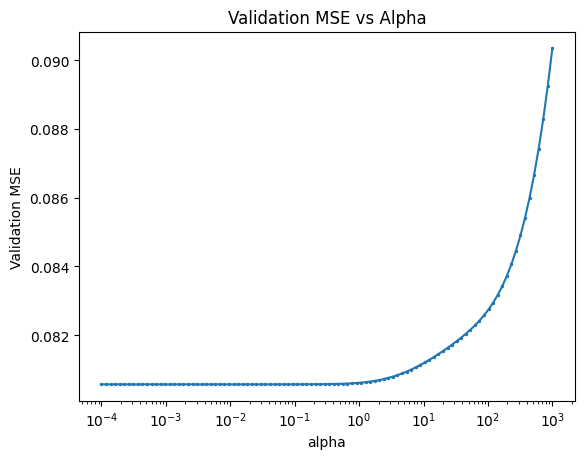

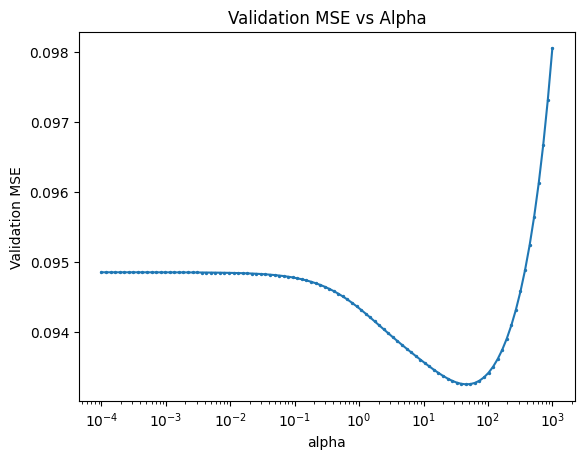

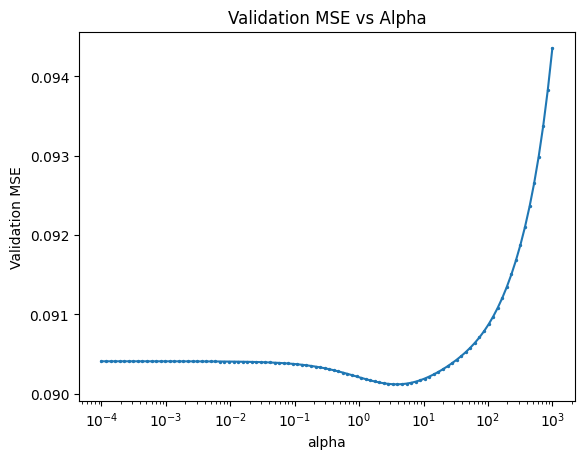

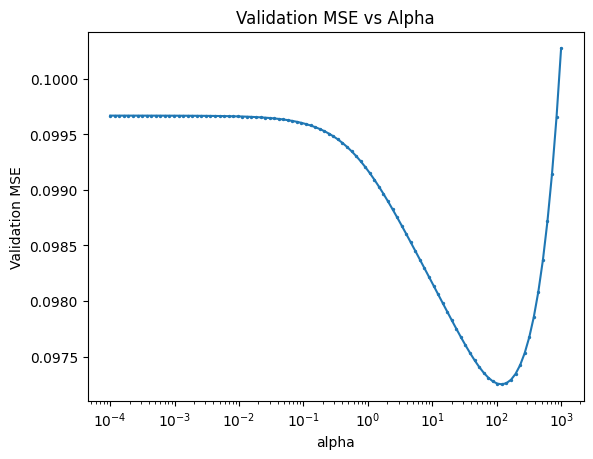

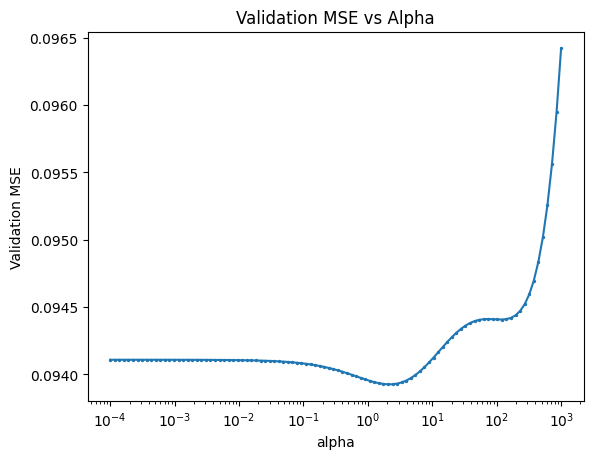

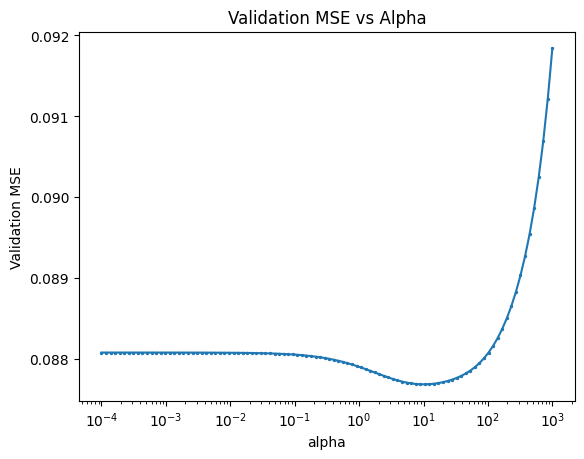

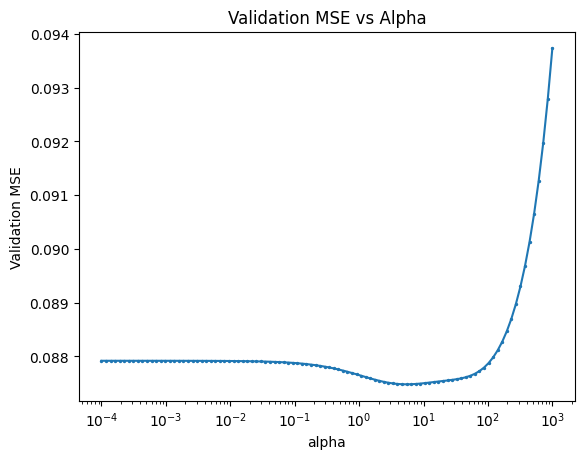

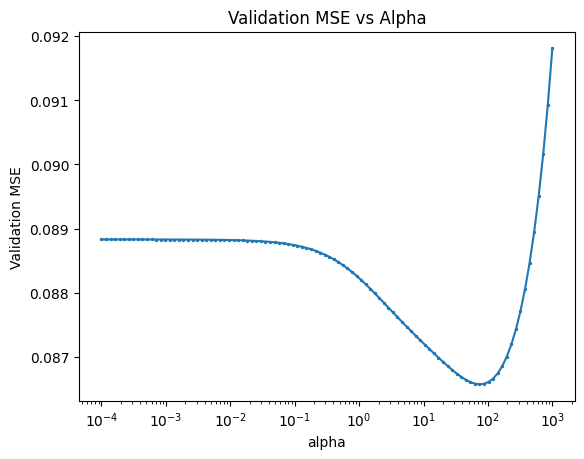

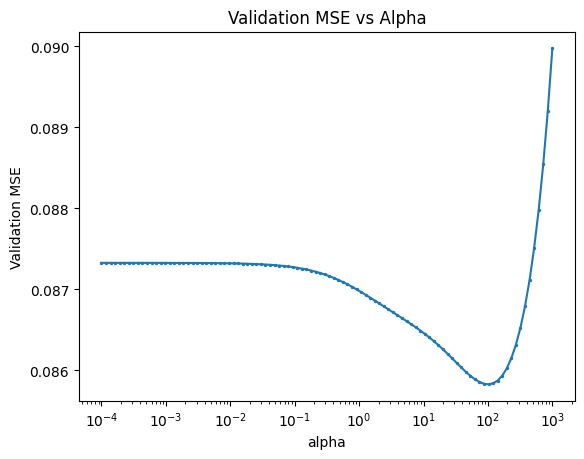

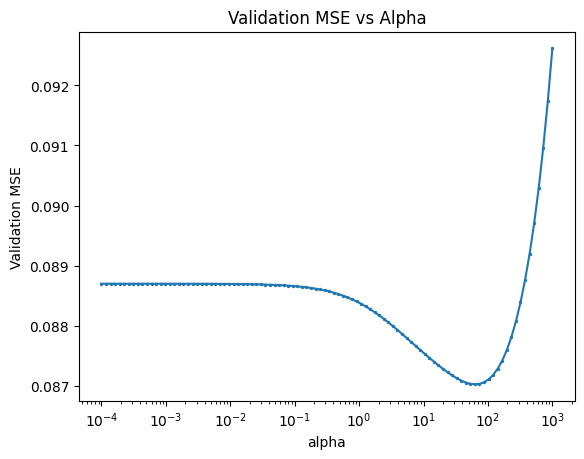

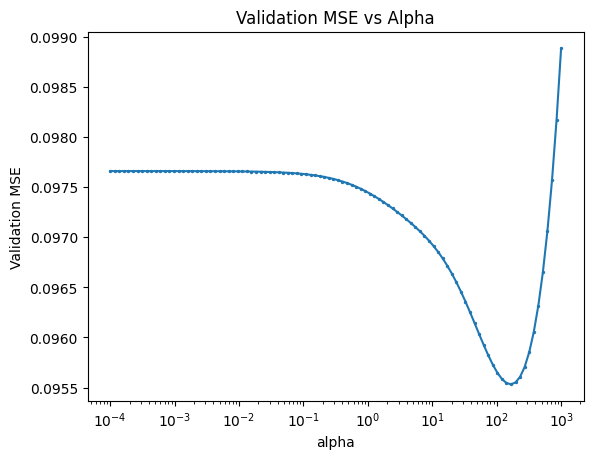

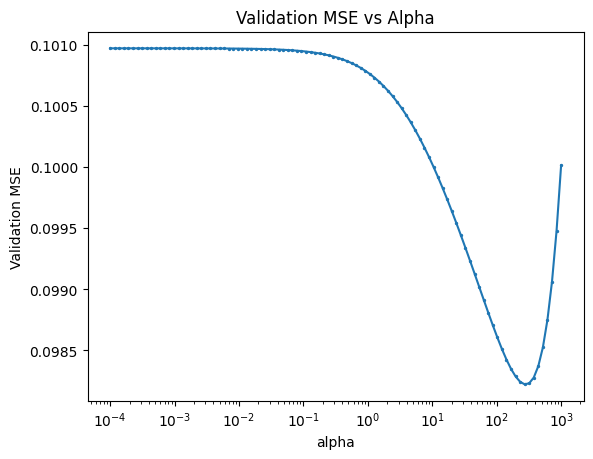

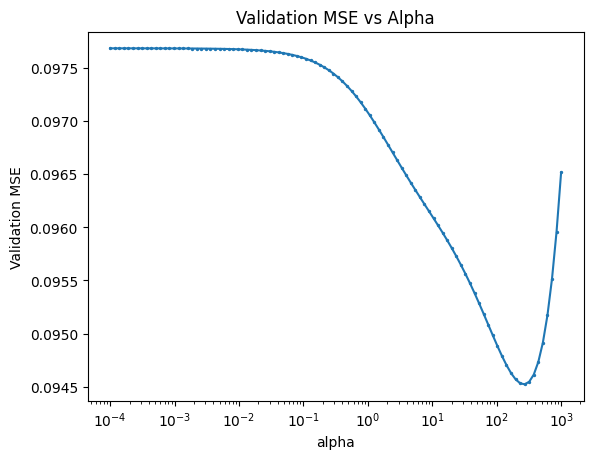

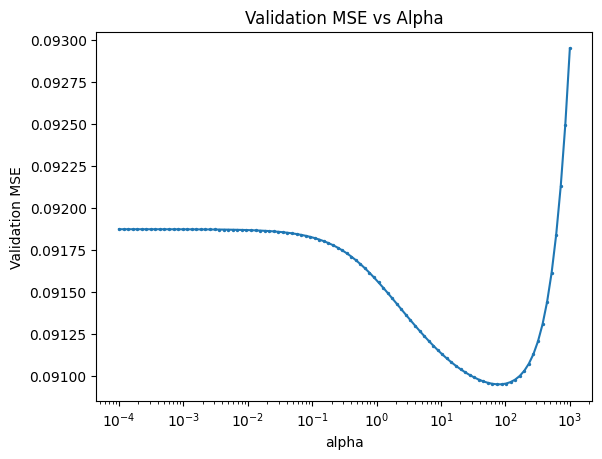

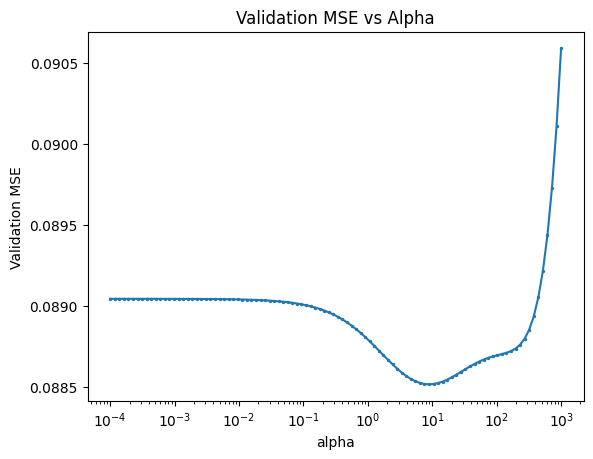

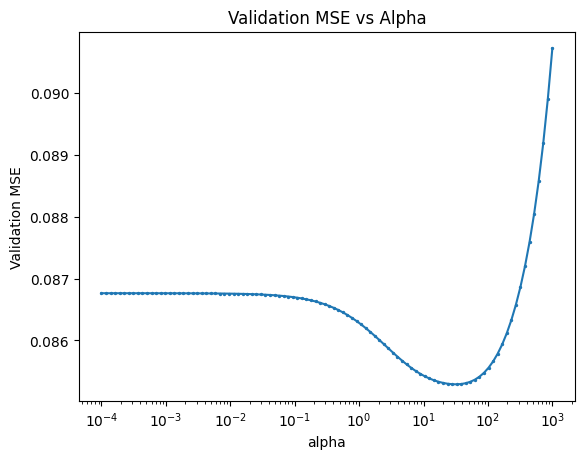

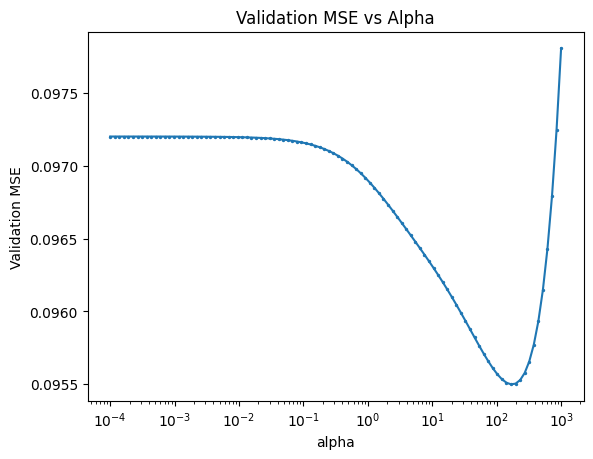

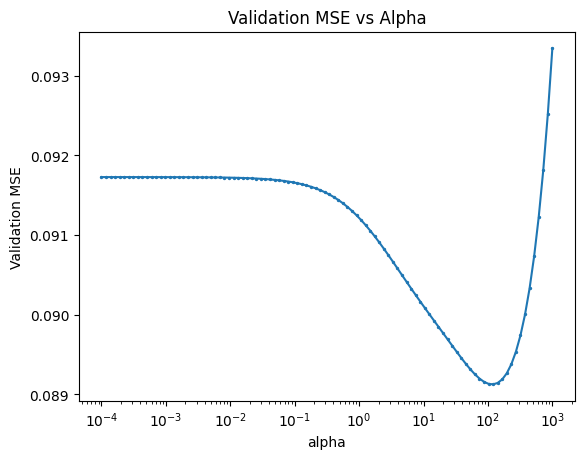

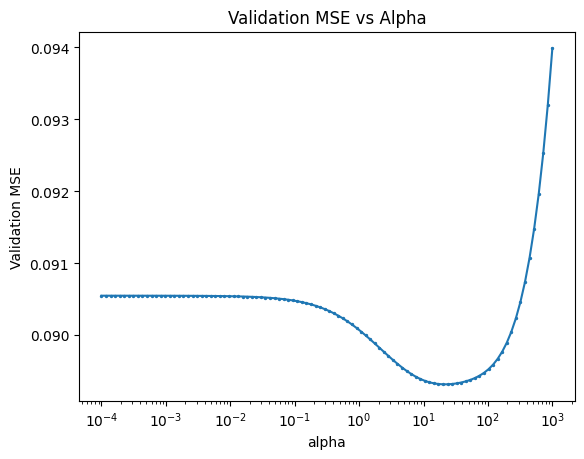

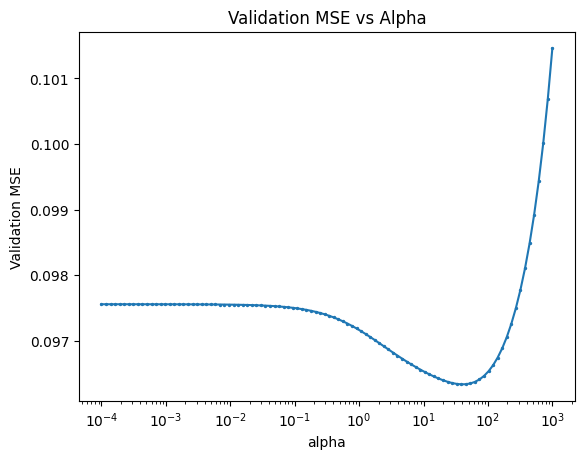

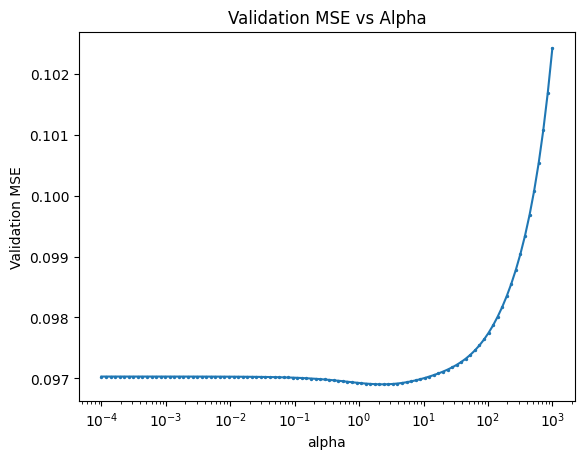

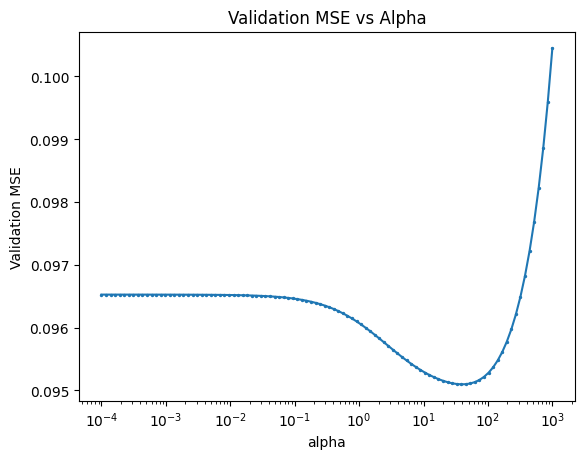

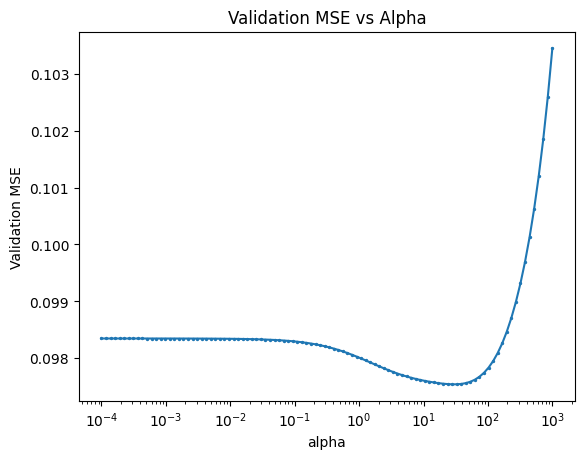

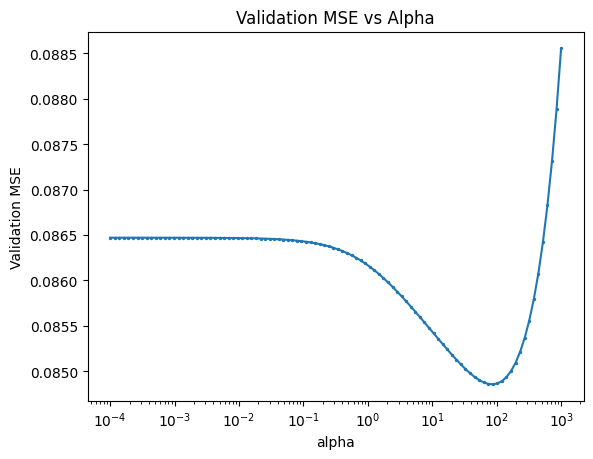

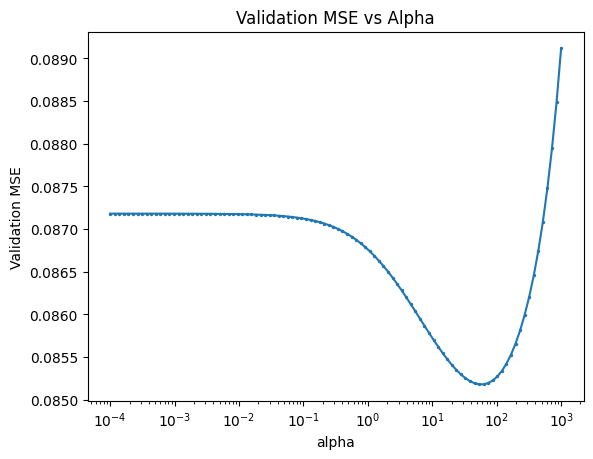

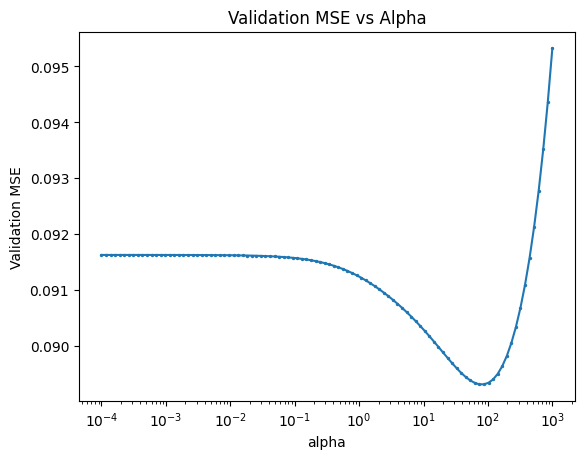

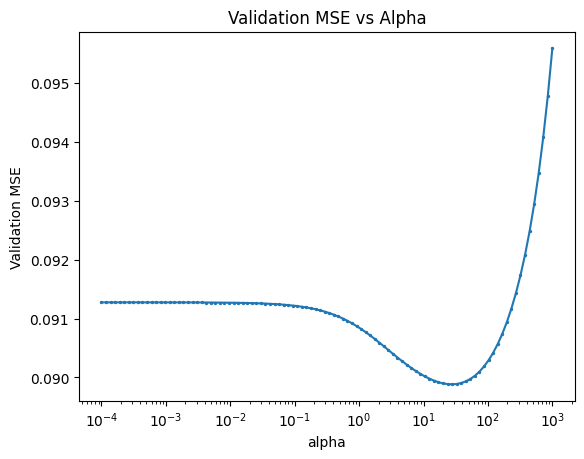

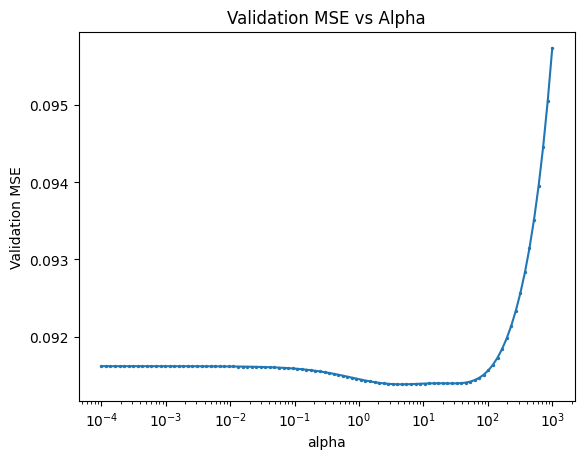

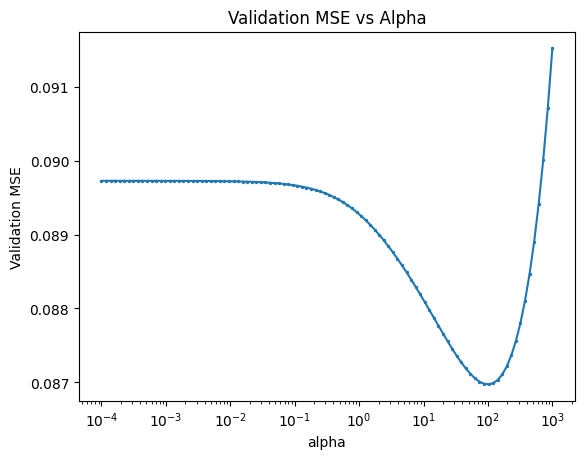

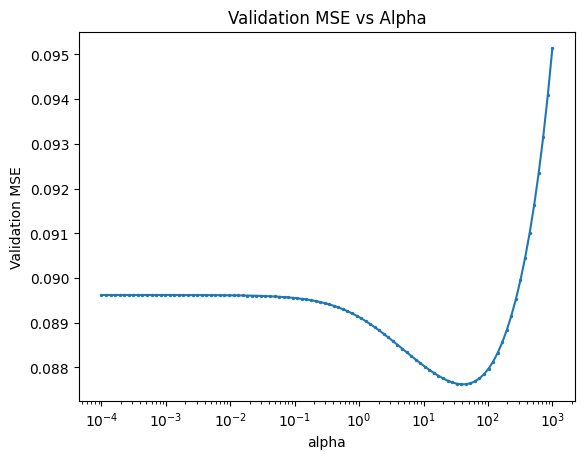

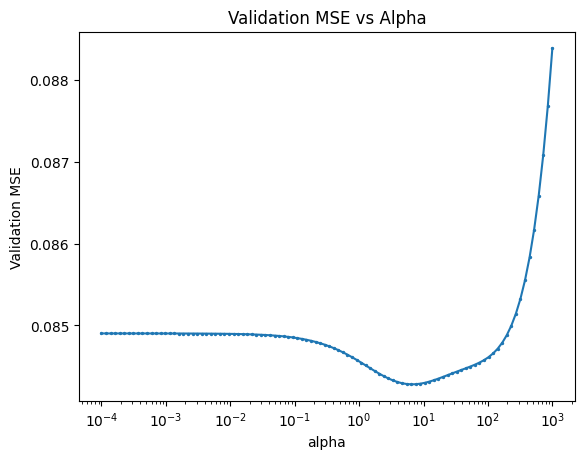

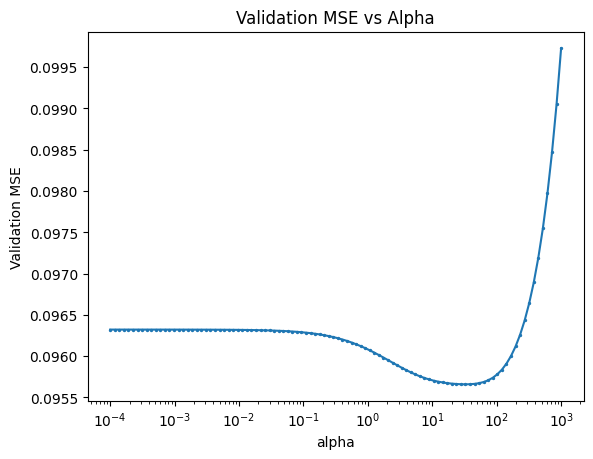

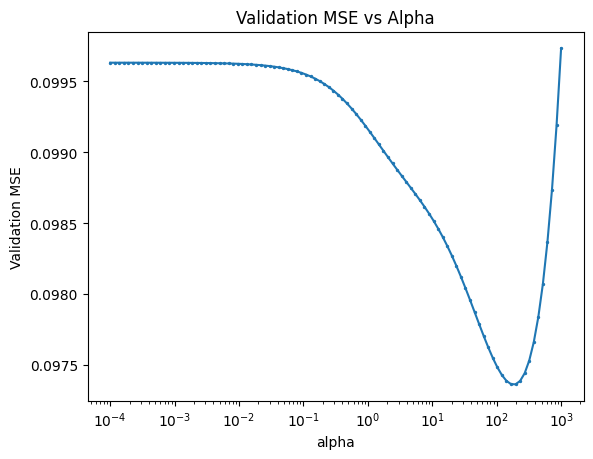

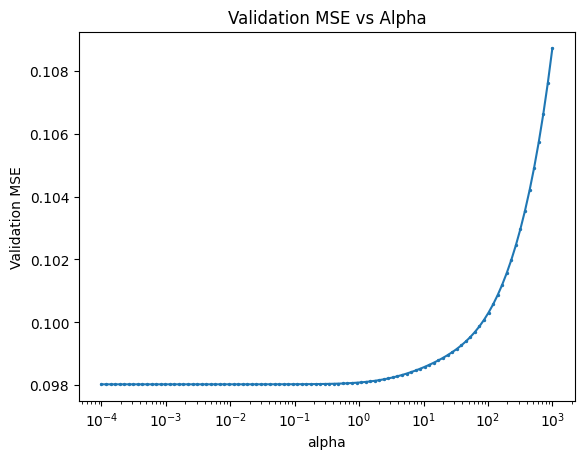

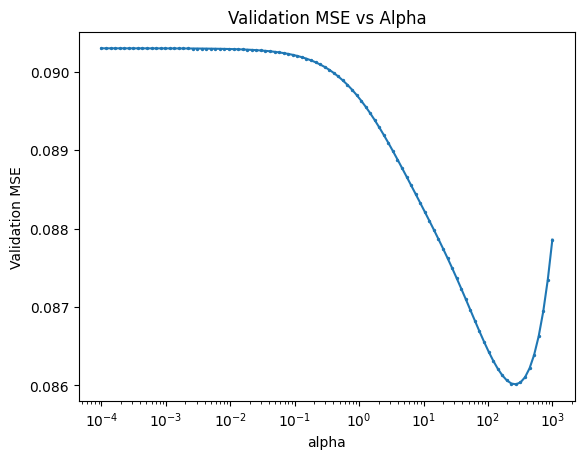

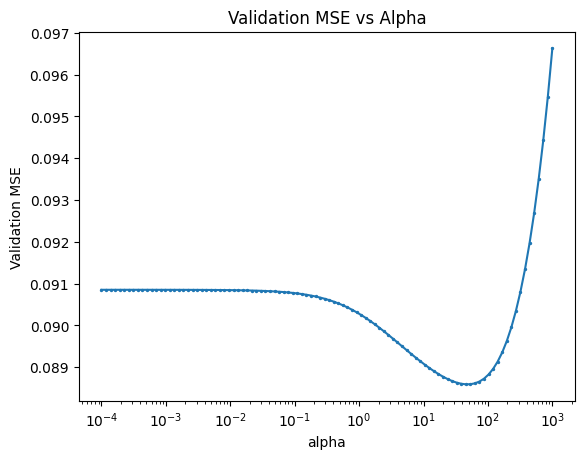

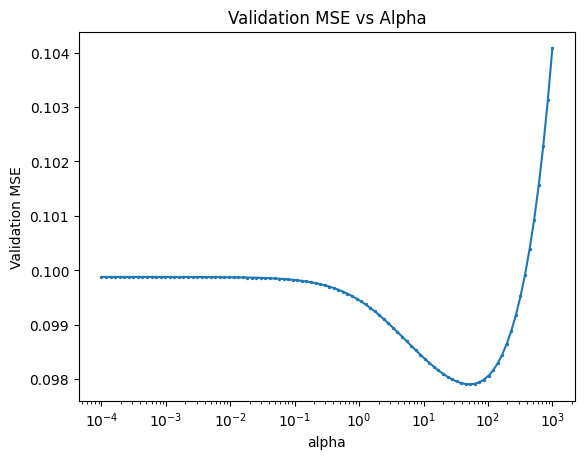

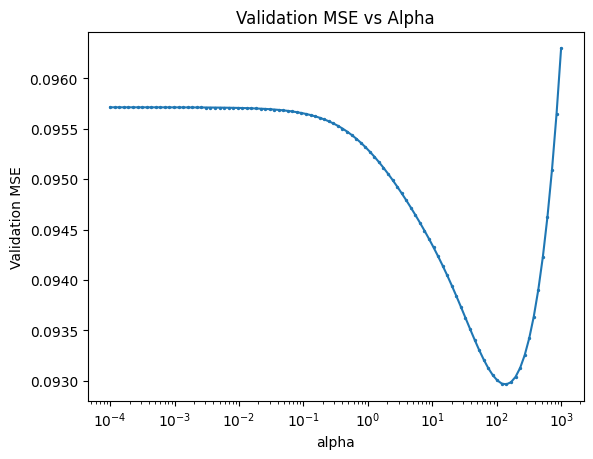

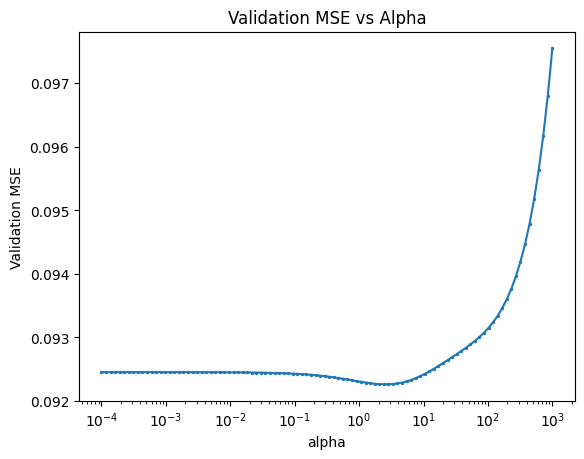

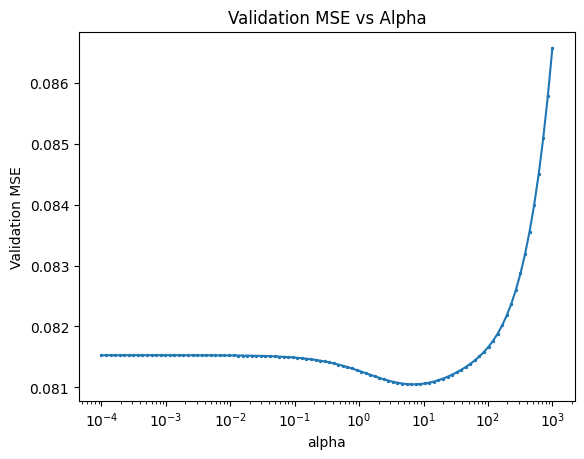

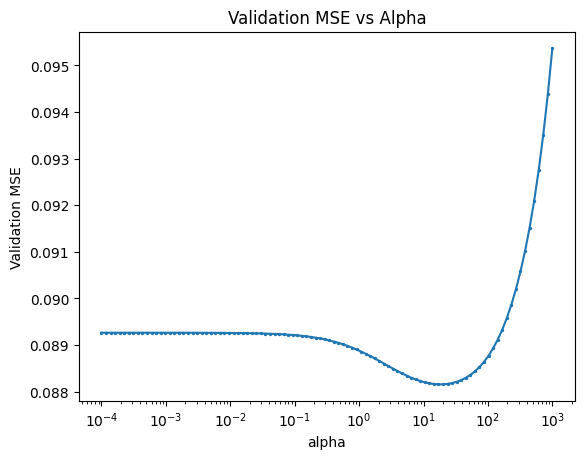

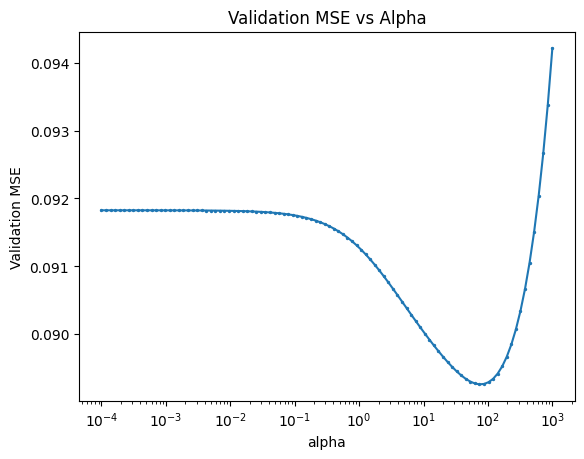

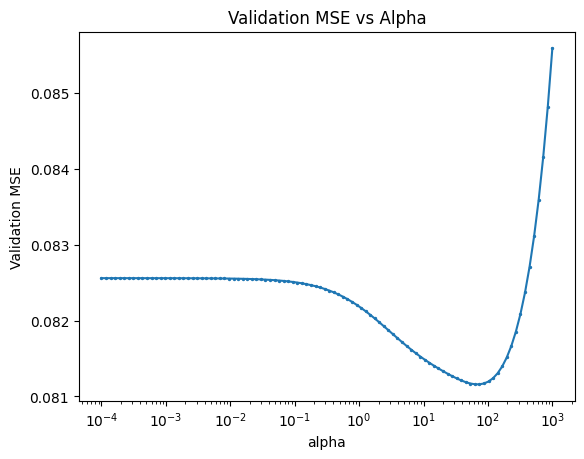

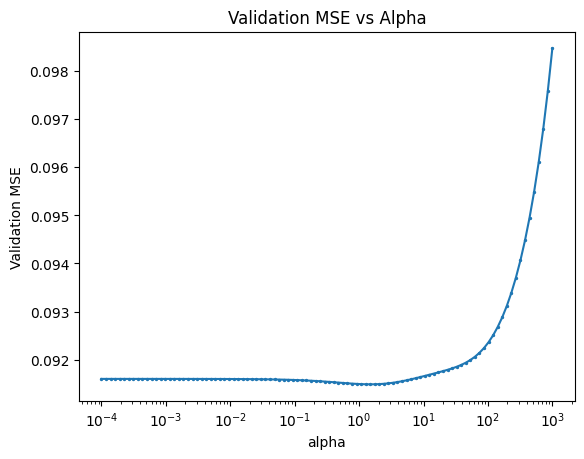

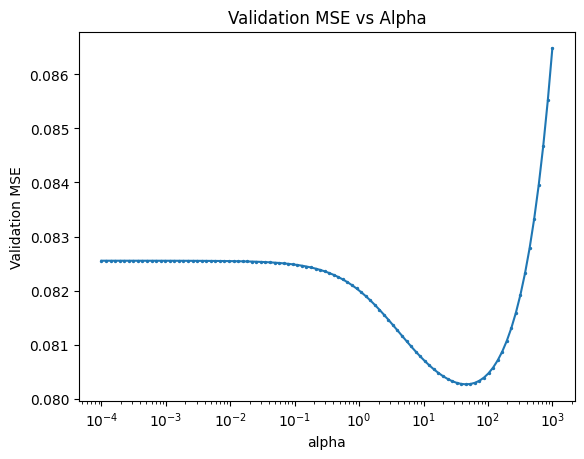

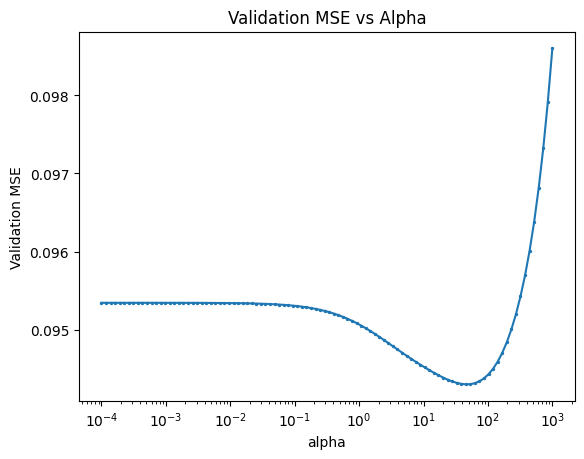

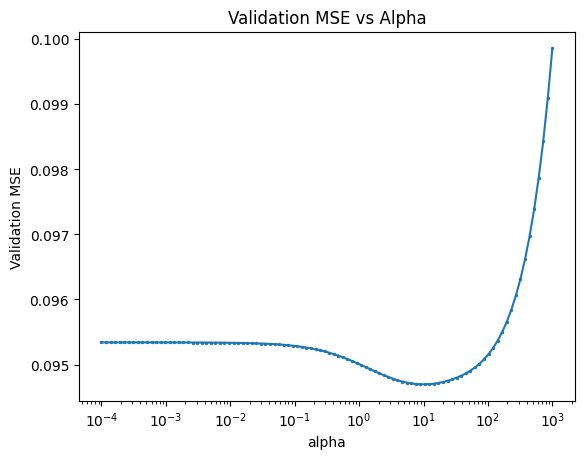

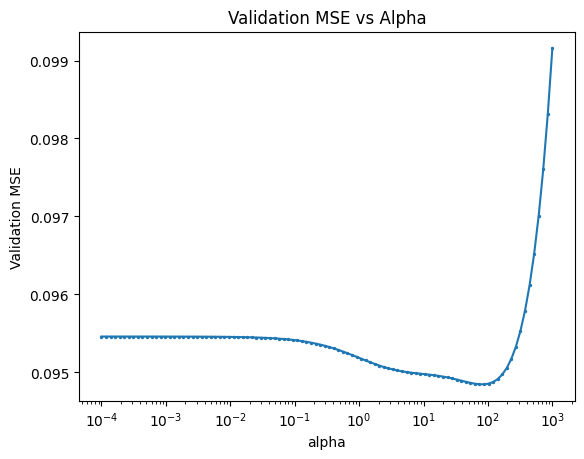

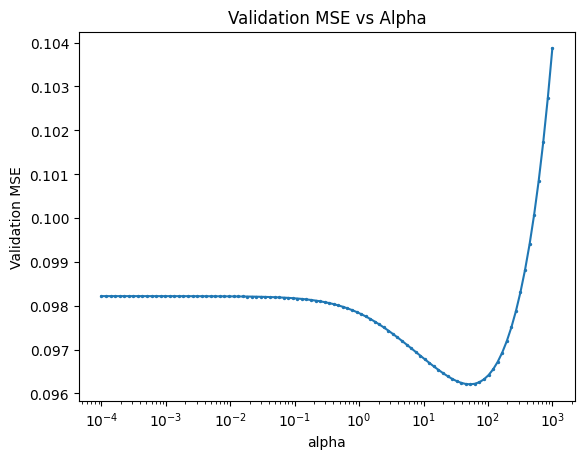

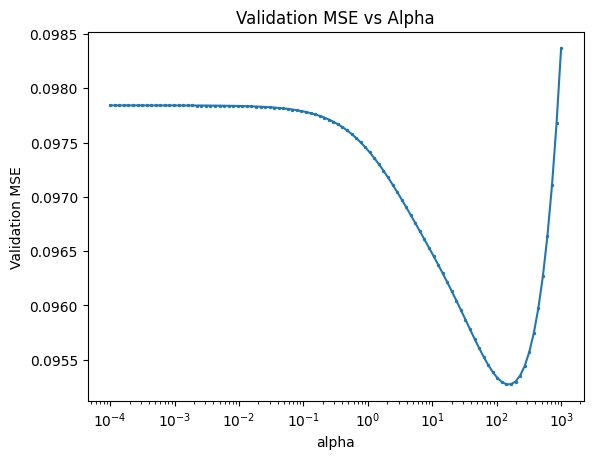

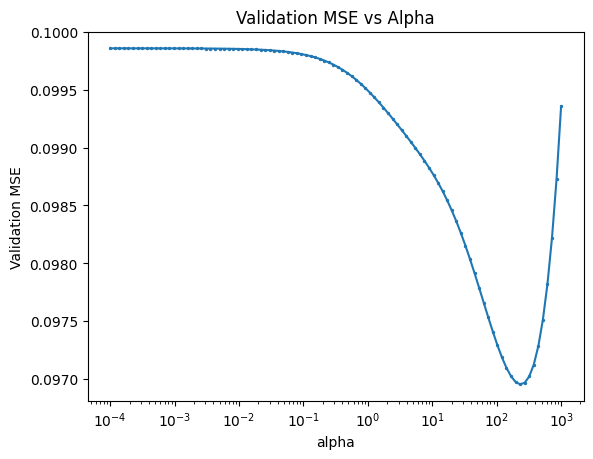

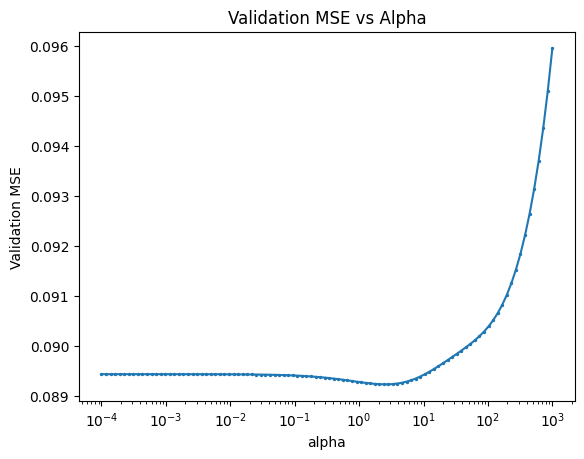

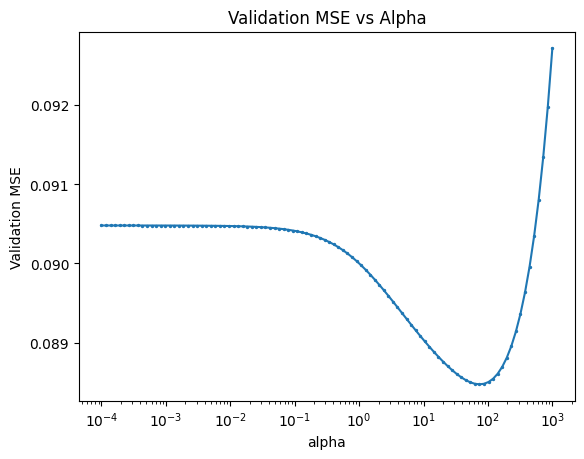

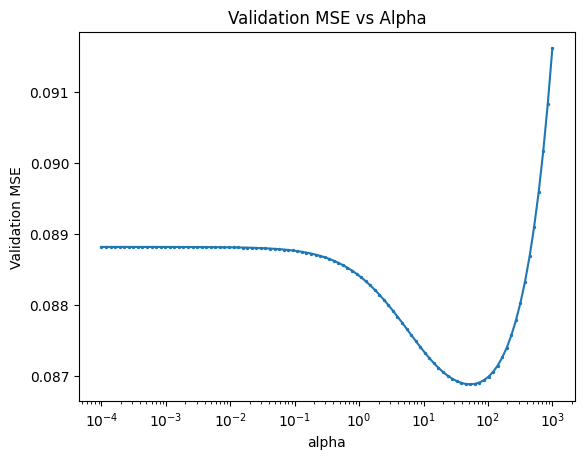

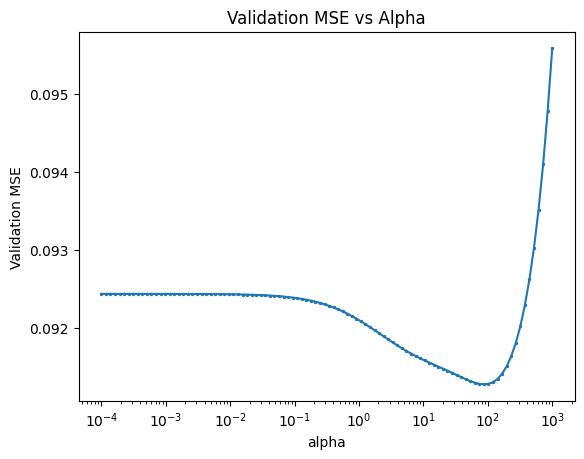

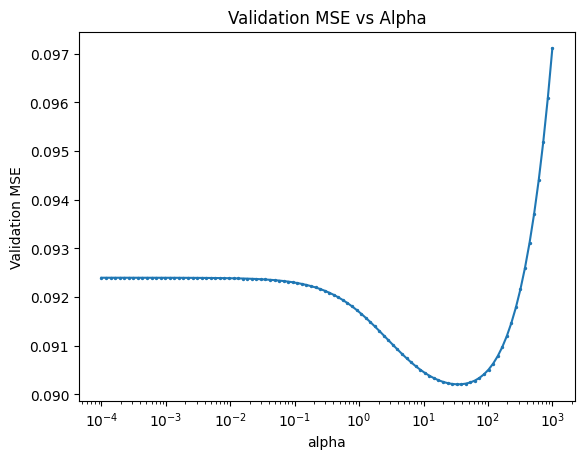

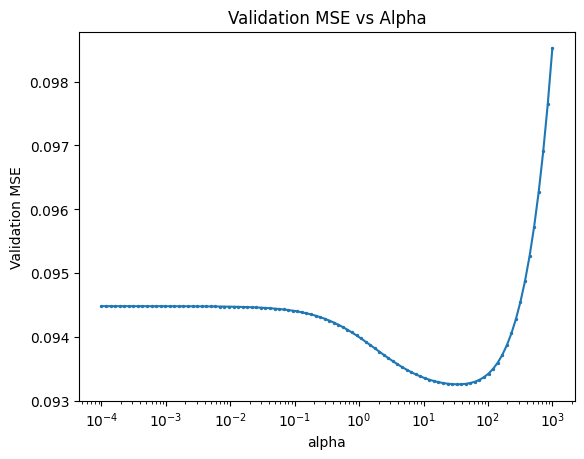

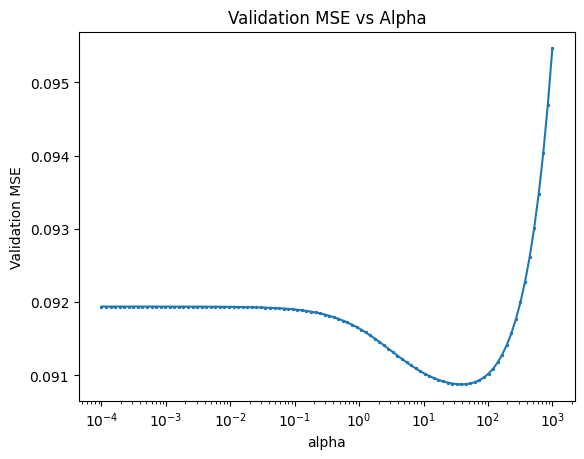

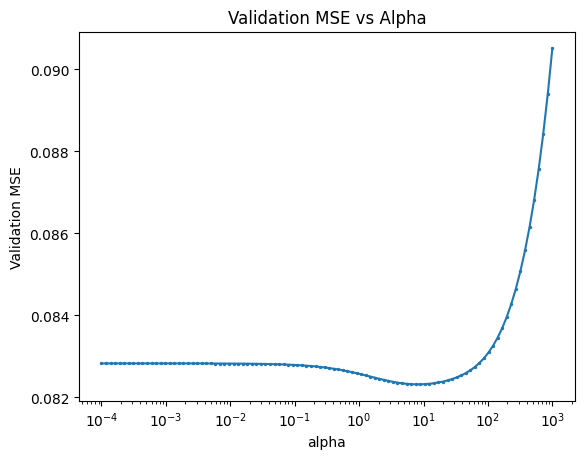

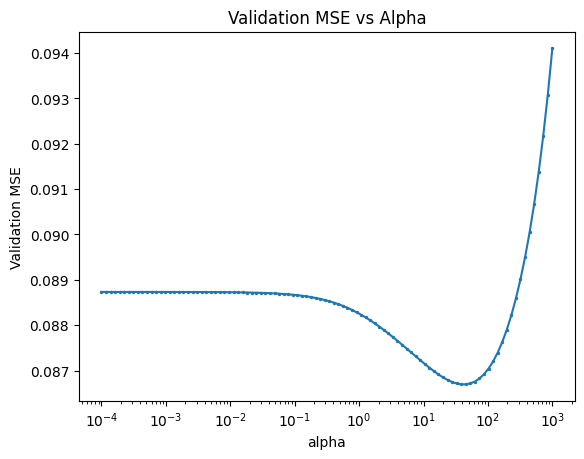

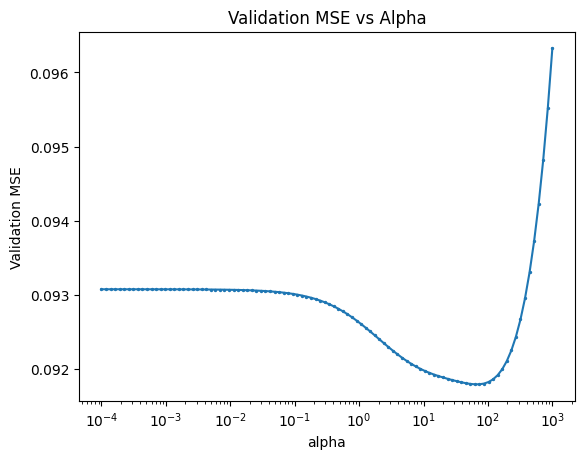

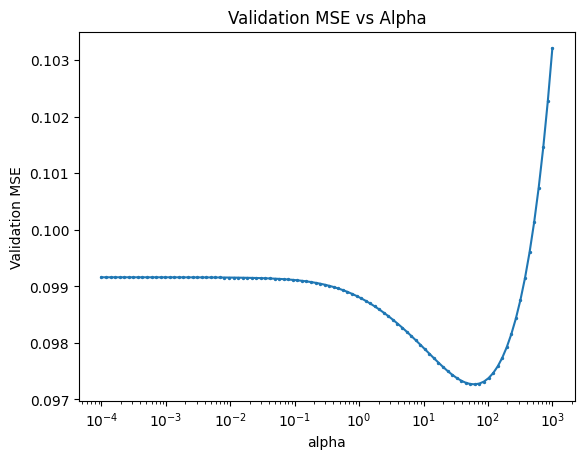

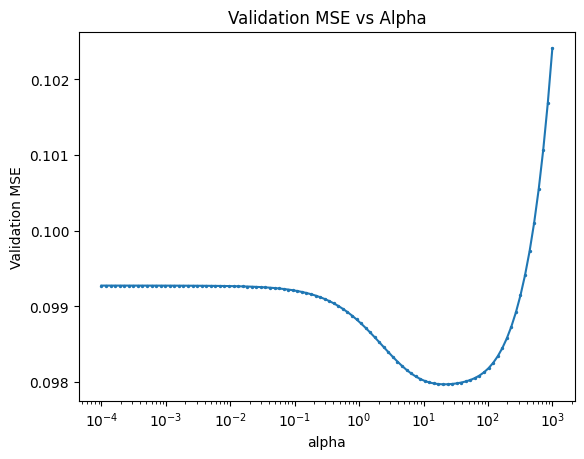

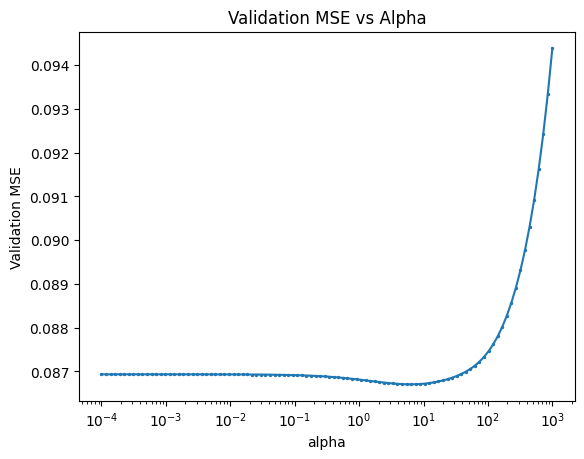

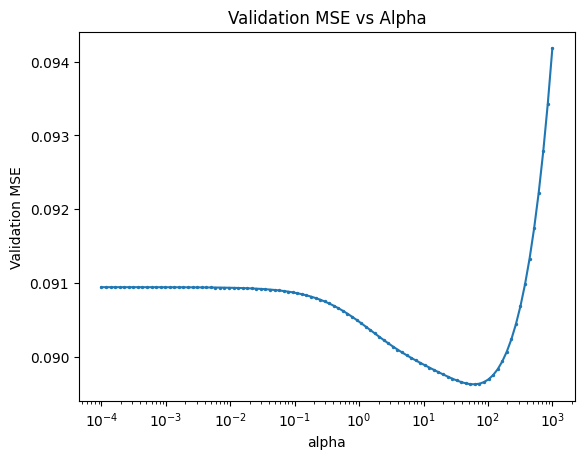

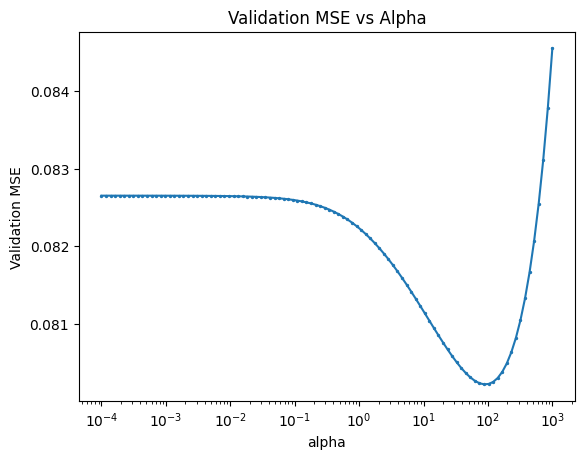

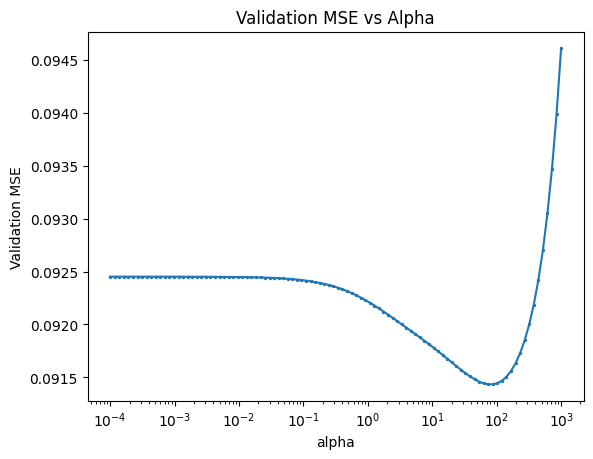

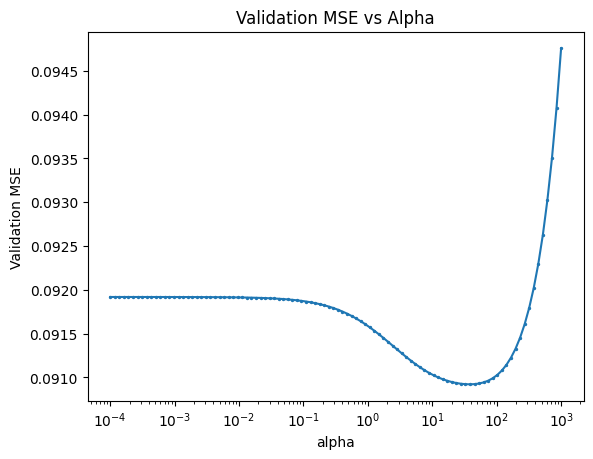

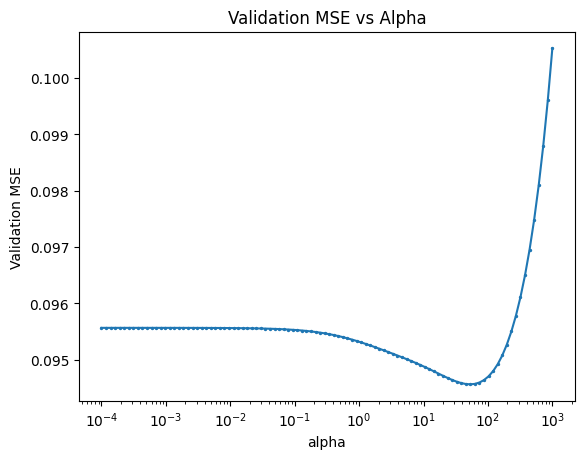

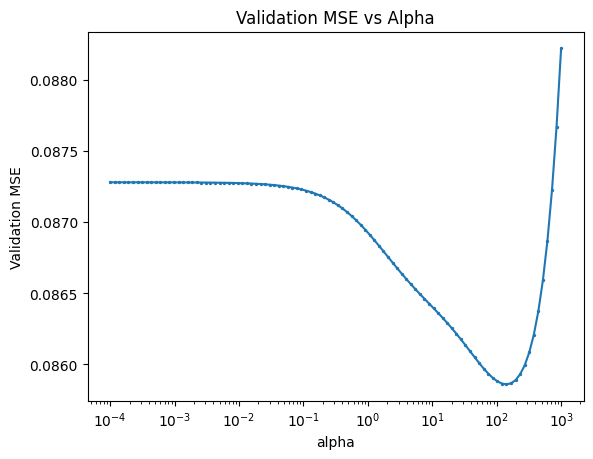

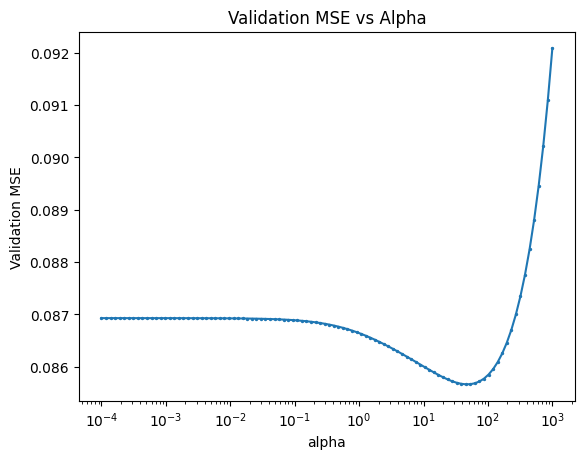

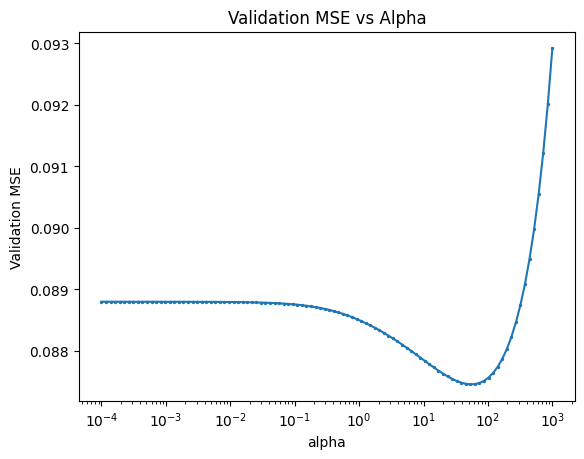

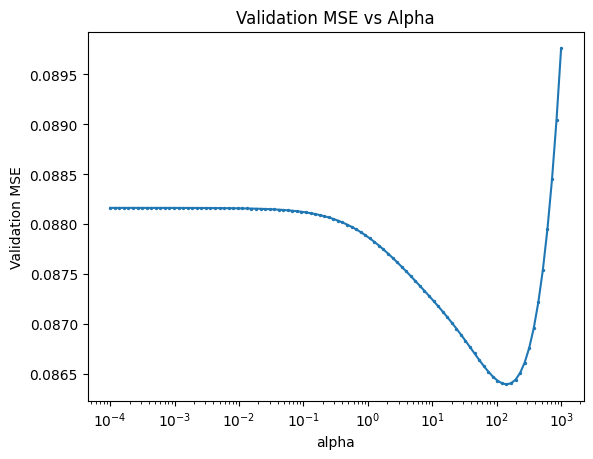

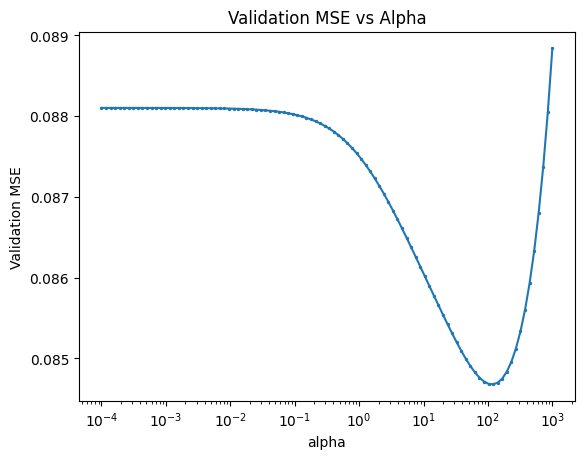

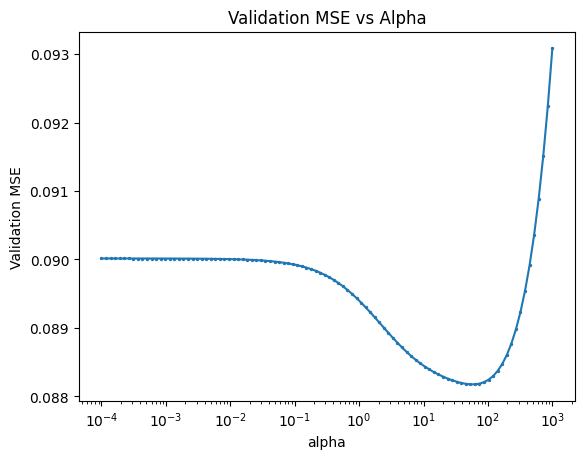

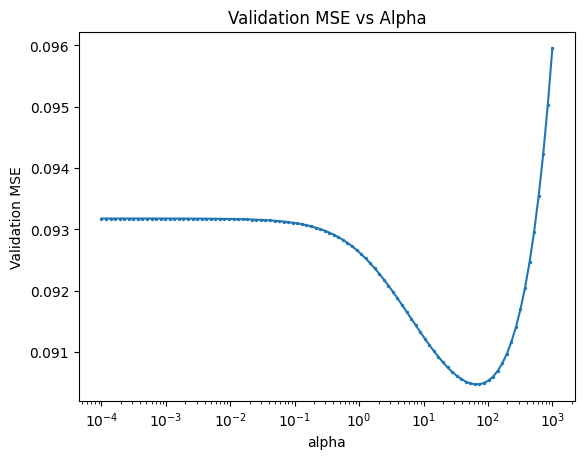

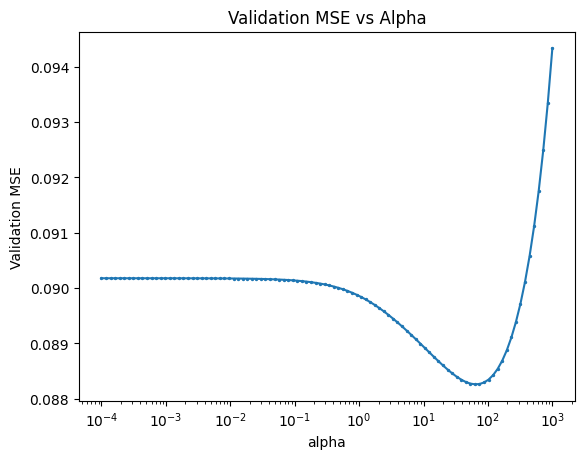

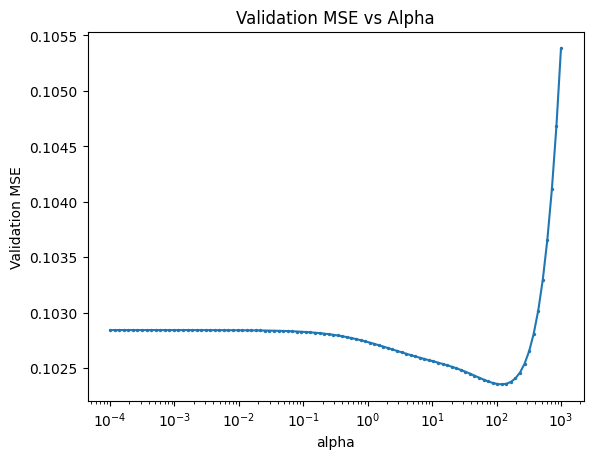

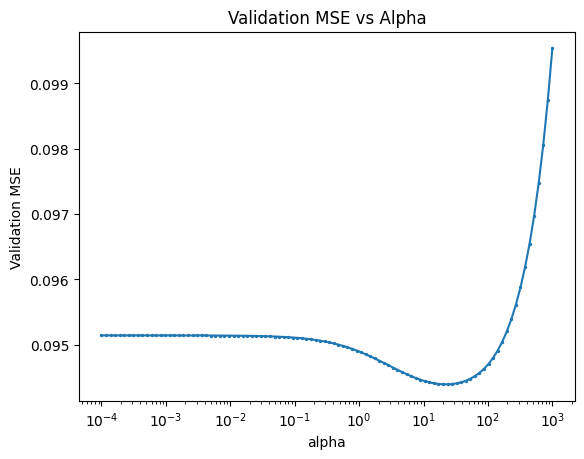

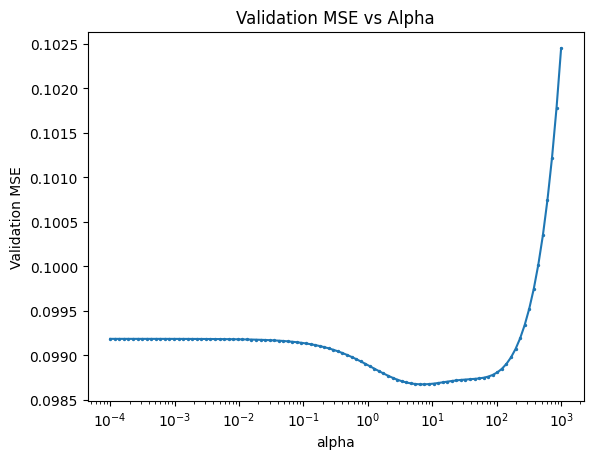

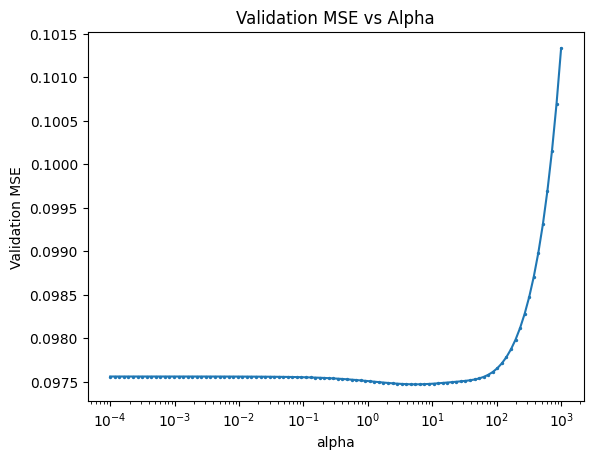

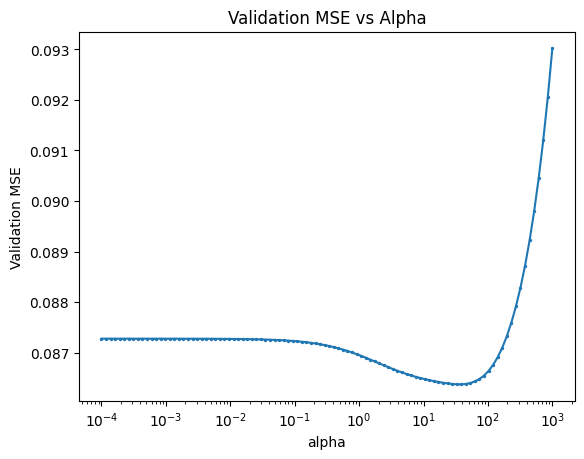

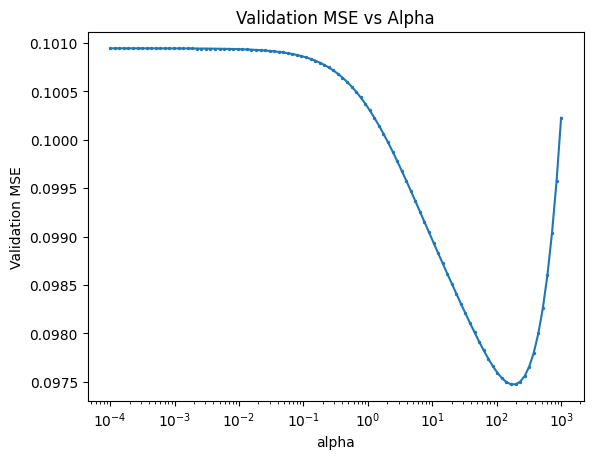

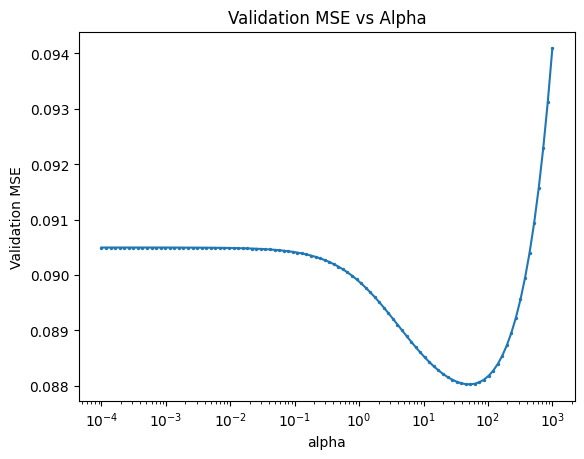

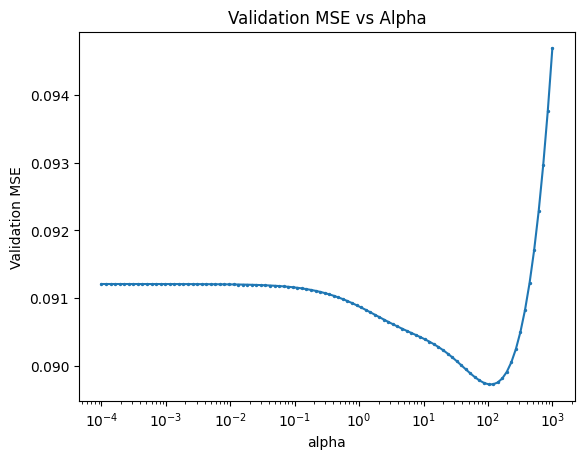

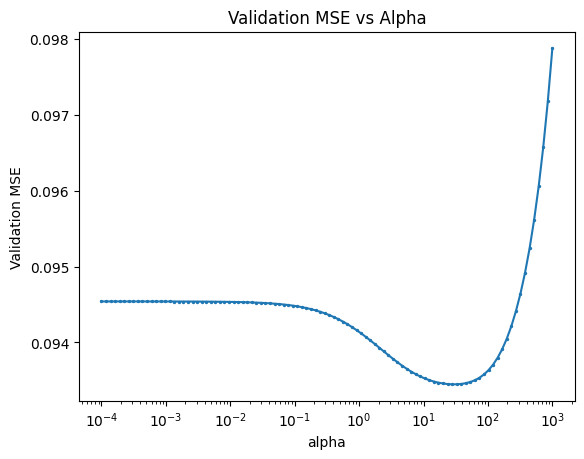

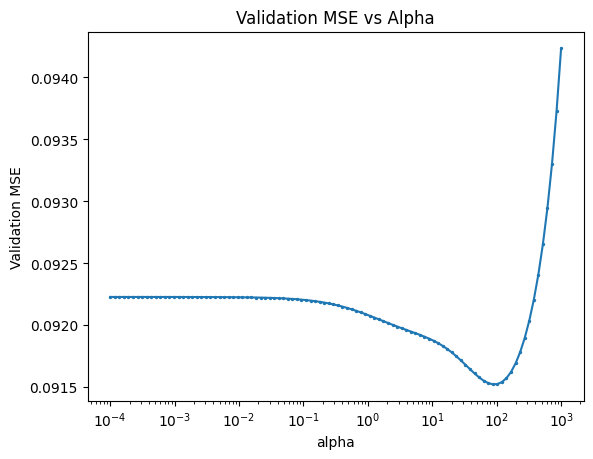

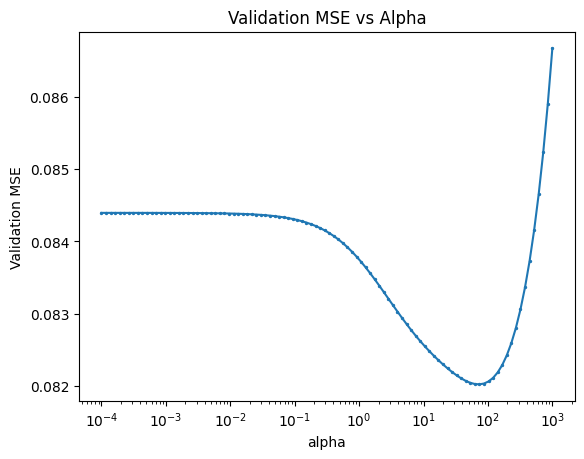

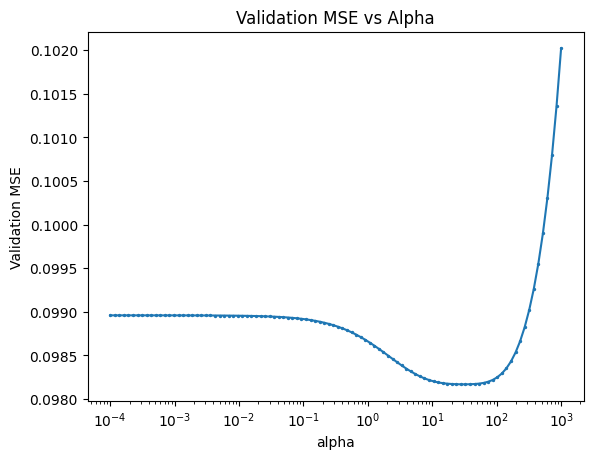

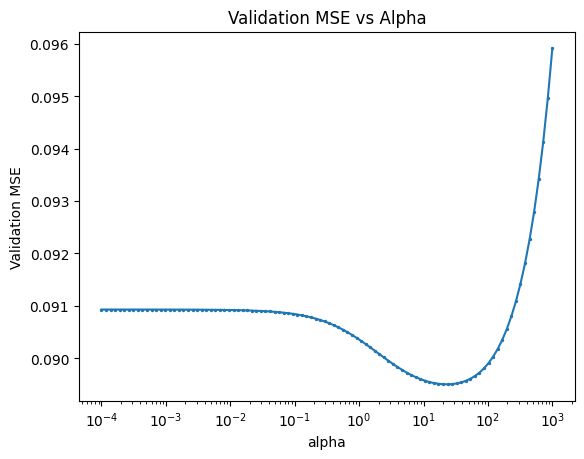

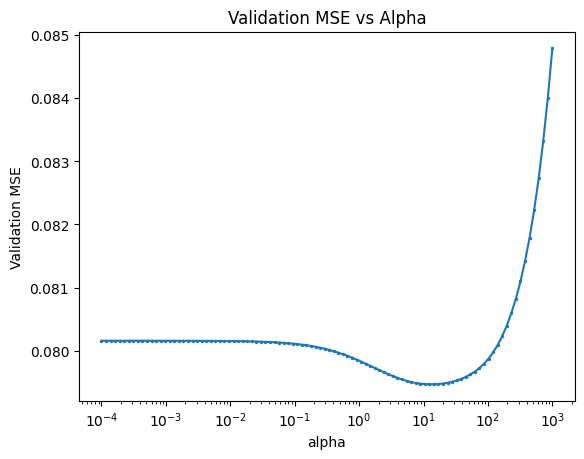

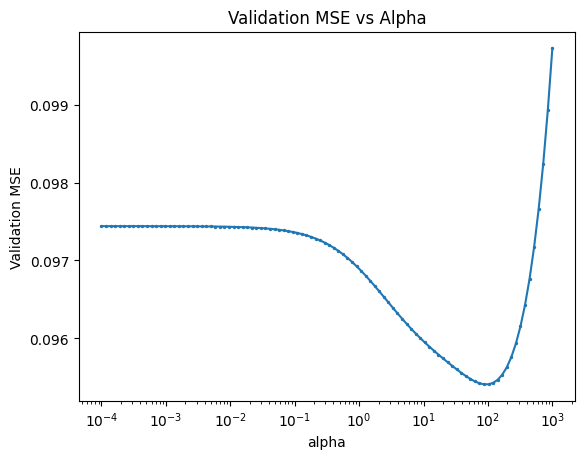

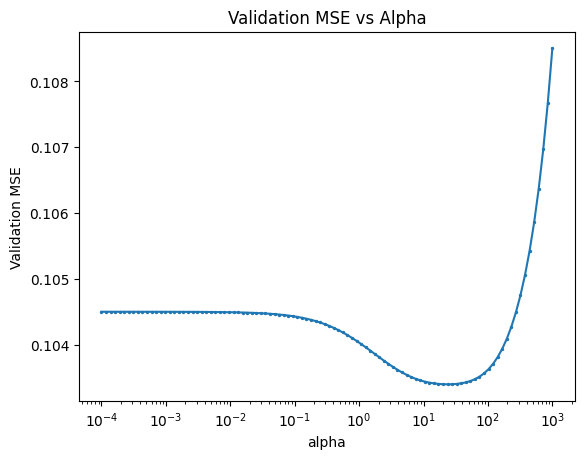

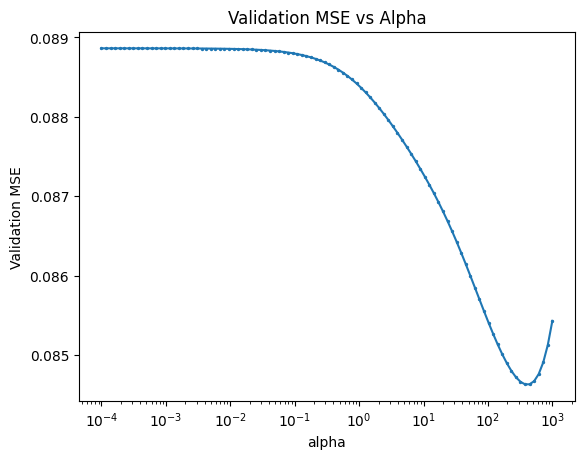

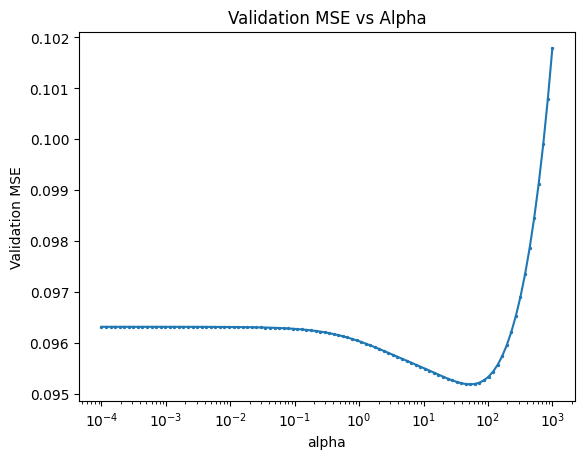

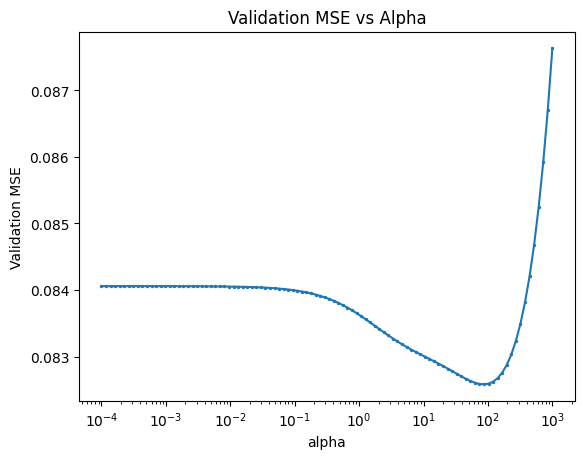

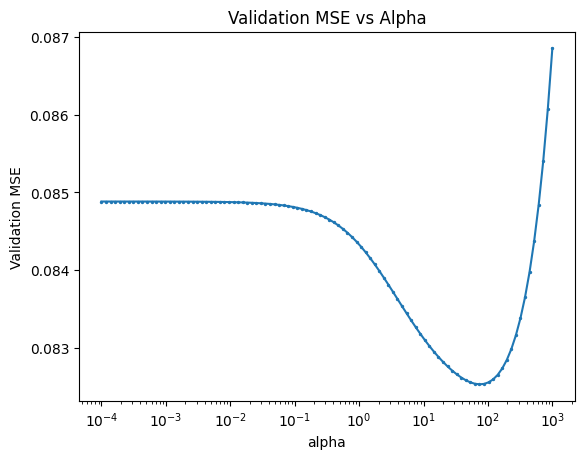

In [33]:
# 80:20 split
mse_idxs = []
for seed in np.arange(0, 200, 2): # 200 for real!
    X_train, X_val, y_train, y_val = train_test_split(
        scaled_data, output, test_size=0.2, random_state=seed
    )

    alphas = np.logspace(-4, 3, 100)
    mses = []
    
    for alpha in alphas:
        model = sklearn.linear_model.Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        mses.append(mean_squared_error(y_val, preds))
    mse_idxs.append(mses.index(min(mses)))

    plt.figure()
    plt.scatter(alphas, mses, s=2)
    plt.plot(alphas, mses)
    plt.xscale('log')
    plt.xlabel('alpha')
    plt.ylabel('Validation MSE')
    plt.title('Validation MSE vs Alpha')
    plt.show()

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  1.,  3.,  1.,  2.,  5.,  3.,  3.,
         1.,  5.,  8.,  6., 16., 14., 11.,  9.,  4.,  4.,  1.]),
 array([ 0.  ,  1.86,  3.72,  5.58,  7.44,  9.3 , 11.16, 13.02, 14.88,
        16.74, 18.6 , 20.46, 22.32, 24.18, 26.04, 27.9 , 29.76, 31.62,
        33.48, 35.34, 37.2 , 39.06, 40.92, 42.78, 44.64, 46.5 , 48.36,
        50.22, 52.08, 53.94, 55.8 , 57.66, 59.52, 61.38, 63.24, 65.1 ,
        66.96, 68.82, 70.68, 72.54, 74.4 , 76.26, 78.12, 79.98, 81.84,
        83.7 , 85.56, 87.42, 89.28, 91.14, 93.  ]),
 <BarContainer object of 50 artists>)

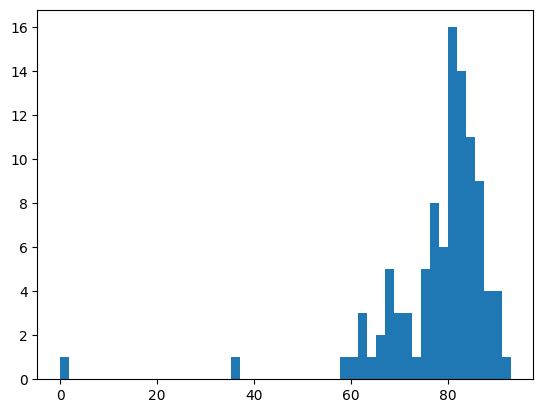

In [34]:
plt.hist(mse_idxs, bins=50)
#plt.savefig(os.path.join(supp_savedir, "mse_hist.svg"))

In [36]:
from sklearn.metrics import mean_squared_error, r2_score
alphas = np.logspace(-3, 3.5, 40)
n_seeds = 50

mse_mat = np.zeros((len(alphas), n_seeds))
r2_mat  = np.zeros((len(alphas), n_seeds))

for a_idx, alpha in enumerate(alphas):

    for seed in range(n_seeds):

        X_train, X_val, y_train, y_val = train_test_split(
            scaled_data,
            output,
            test_size=0.2,
            random_state=seed
        )

        model = sklearn.linear_model.Ridge(alpha=alpha).fit(X_train, y_train)

        preds = model.predict(X_val)

        mse_mat[a_idx, seed] = mean_squared_error(y_val, preds)
        r2_mat[a_idx, seed]  = r2_score(y_val, preds)

mse_mean = mse_mat.mean(axis=1)
mse_std  = mse_mat.std(axis=1)

r2_mean = r2_mat.mean(axis=1)
r2_std  = r2_mat.std(axis=1)

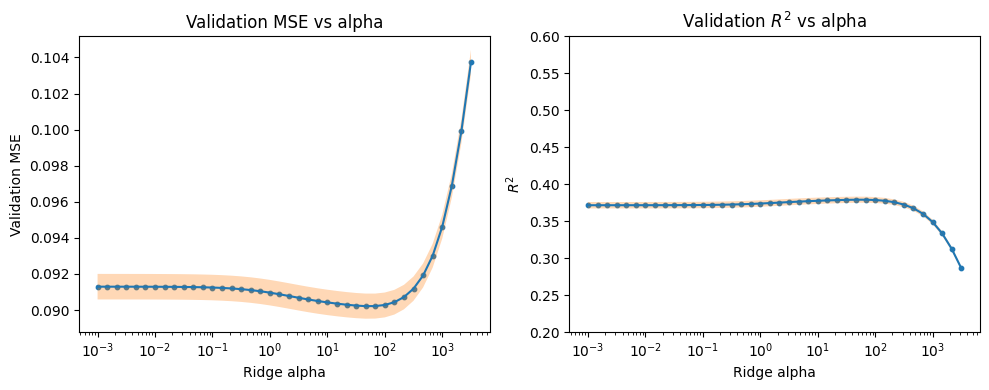

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# MSE
axes[0].plot(alphas, mse_mean)
axes[0].scatter(alphas, mse_mean,s=10)
mse_sem = mse_std / np.sqrt(n_seeds)


axes[0].fill_between(
    alphas,
    mse_mean - mse_sem,
    mse_mean + mse_sem,
    alpha=0.3
)
axes[0].set_xscale('log')
axes[0].set_xlabel('Ridge alpha')
axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Validation MSE vs alpha')
axes[1].set_ylim([0,0.2])
# R²
axes[1].plot(alphas, r2_mean)
axes[1].scatter(alphas, r2_mean, s=10)

r2_sem  = r2_std  / np.sqrt(n_seeds)

axes[1].fill_between(
    alphas,
    r2_mean - r2_sem,
    r2_mean + r2_sem,
    alpha=0.3
)
axes[1].set_xscale('log')
axes[1].set_xlabel('Ridge alpha')
axes[1].set_ylabel(r'$R^2$')
axes[1].set_title(r'Validation $R^2$ vs alpha')
axes[1].set_ylim([0.2,0.6])
plt.tight_layout()
#plt.savefig(os.path.join(supp_savedir, 'mse_r2_vs_alpha.svg'))
plt.show()

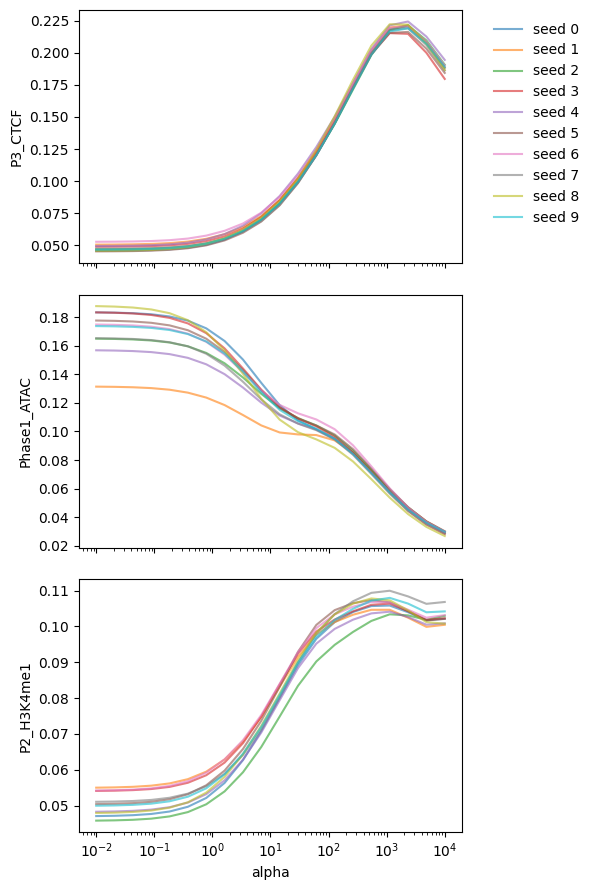

In [318]:
alphas = np.logspace(-2, 4, 20)
n_seeds = 10
features_to_plot = [6, 7, 12]
strengths = np.zeros((len(alphas), n_seeds, num_features))

for a_idx, alpha in enumerate(alphas):
    for seed in range(n_seeds):

        X_train, X_val, y_train, y_val = train_test_split(
            scaled_data,
            output,
            test_size=0.2,
            random_state=seed
        )

        model = Ridge(alpha=alpha).fit(X_train, y_train)

        coefs = model.coef_.reshape(num_features, num_bins)

        feat_strength = np.linalg.norm(coefs, axis=1)
        feat_strength /= feat_strength.sum()

        strengths[a_idx, seed] = feat_strength


fig, axes = plt.subplots(
    len(features_to_plot),
    1,
    figsize=(6, 3*len(features_to_plot)),
    sharex=True
)

for ax, feat_idx in zip(np.atleast_1d(axes), features_to_plot):

    for seed in range(n_seeds):
        ax.plot(
            alphas,
            strengths[:, seed, feat_idx],
            alpha=0.6,
            label=f"seed {seed}" if feat_idx == features_to_plot[0] else None
        )

    ax.set_xscale("log")
    ax.set_ylabel(features[feat_idx])

axes[-1].set_xlabel("alpha")
axes[0].legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
#plt.savefig(os.path.join(supp_savedir, "feat_stability_alpha.svg"))
plt.show()

In [35]:
# there's a bump at around 65 and 80. 
alpha_use=65

In [36]:
np.shape(coefs)

NameError: name 'coefs' is not defined

In [39]:
strengths = []
min_mses = []

for seed in range(10):
    X_train, X_val, y_train, y_val = train_test_split(
        scaled_data, output, test_size=0.2, random_state=seed
    )
    model = sklearn.linear_model.Ridge(alpha=alpha_use).fit(X_train, y_train)
    coefs = model.coef_.reshape(num_features, num_bins)
    feat_strength = np.linalg.norm(coefs, axis=1)
    feat_strength = feat_strength / feat_strength.sum()
    strengths.append(feat_strength)
    
    preds = model.predict(X_val)
    mses.append(mean_squared_error(y_val, preds))

strengths = np.array(strengths)  # shape: (5, 24)

In [40]:
np.shape(coefs)

(17, 10)

['P1_H3K27ac', 'P1_H3K4me1', 'P2_CTCF', 'P1_CTCF', 'Phase1_RNA_chr', 'P3_H3K27ac', 'P3_CTCF', 'Phase1_ATAC', 'Phase2_RNA_chr', 'Phase3_ATAC', 'Phase3_RNA_chr', 'P2_H3K27ac', 'P2_H3K4me1', 'Phase2_ATAC', 'E1_P1', 'E1_P2', 'E1_P3']


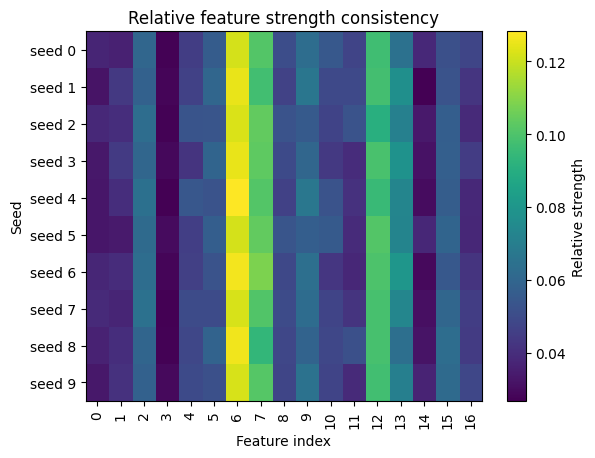

In [41]:
plt.figure()
print(features)
plt.imshow(strengths, aspect="auto")
plt.colorbar(label="Relative strength")
plt.yticks(range(10), [f"seed {s}" for s in range(10)])
plt.xticks(range(num_features), range(num_features), rotation=90)
plt.xlabel("Feature index")
plt.ylabel("Seed")
plt.title("Relative feature strength consistency")
plt.savefig(os.path.join(supp_savedir, "feature_strength_consistency.svg"))
plt.show()

In [42]:
strengths=np.mean(strengths, axis=0)

In [53]:

def reshape_ridge_coefs(model, n_features, n_bins):
    """
    Reshape flattened ridge coefficients into (n_features, n_bins).
    """
    coef = model.coef_
    assert coef.shape[0] == n_features * n_bins
    return coef.reshape(n_features, n_bins)

def plot_feature_distance_coefs(coef_fb, feature_names, bin_centers=None):
    """
    coef_fb: array (n_features, n_bins)
    feature_names: list of length n_features
    bin_centers: optional array of length n_bins (e.g. distances in kb)
    """
    n_features, n_bins = coef_fb.shape

    if bin_centers is None:
        x = np.arange(n_bins)
        xlabel = "Distance bin"
    else:
        x = bin_centers
        xlabel = "Distance from center"

    plt.figure(figsize=(8, 5))

    for f in range(n_features):
        plt.plot(x, coef_fb[f], label=feature_names[f])

    plt.axhline(0, color='k', lw=1, alpha=0.5)
    plt.xlabel(xlabel)
    plt.ylabel("Ridge coefficient")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_per_feature_panels(coef_fb, feature_names, bin_centers=None, sd=None):
    n_features, n_bins = coef_fb.shape

    if bin_centers is None:
        x = np.arange(n_bins)
        xlabel = "Distance bin"
    else:
        x = bin_centers
        xlabel = "Distance from center"

    fig, axs = plt.subplots(
        n_features, 1,
        figsize=(6, 2.5 * n_features),
        sharex=True
    )

    if n_features == 1:
        axs = [axs]

    for f, ax in enumerate(axs):
        ax.plot(x, coef_fb[f], lw=2)
        ax.axhline(0, color='k', lw=1, alpha=0.5)
        ax.set_ylabel(feature_names[f])

    axs[-1].set_xlabel(xlabel)
    plt.tight_layout()
    if sd is not None:
        plt.savefig(sd)
    else:   
        plt.show()

def plot_coef_heatmap(coef_fb, feature_names, bin_centers=None, sd=None):
    # total positive coefficient mass across all bins
    strengths = np.sum(
        np.clip(coef_fb, a_min=0, a_max=None),
        axis=1
    )

    order = np.argsort(-strengths)

    coef_fb = coef_fb[order]
    feature_names = [feature_names[i] for i in order]

    plt.figure(figsize=(8, 6))
    im = plt.imshow(coef_fb, aspect='auto', cmap='coolwarm', vmax=0.1, vmin=-0.1)
    plt.colorbar(im, label='Ridge coefficient')

    plt.yticks(np.arange(len(feature_names)), feature_names)

    if bin_centers is None:
        plt.xticks(np.arange(coef_fb.shape[1]))
        plt.xlabel("Distance bin")
    else:
        plt.xticks(np.arange(len(bin_centers)), bin_centers)
        plt.xlabel("Distance from center")

    plt.ylabel("Feature (sorted by aggregate positive coefficient)")
    plt.tight_layout()
    
    if sd is not None:
        plt.savefig(sd)
    else:   
        plt.show()

In [54]:
ridgePred = sklearn.linear_model.Ridge(alpha=alpha_use)
fitted = ridgePred.fit(scaled_data, output)
print(ridgePred.score(scaled_data, output))

0.4251188851795059


In [55]:
reshaped = reshape_ridge_coefs(ridgePred, len(features), np.shape(binned_inputs)[2])

In [56]:
phase='P3'

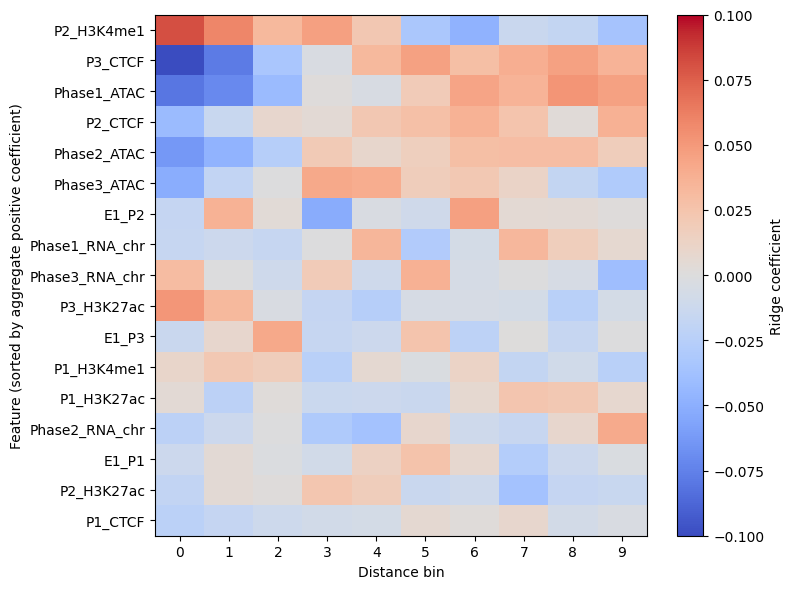

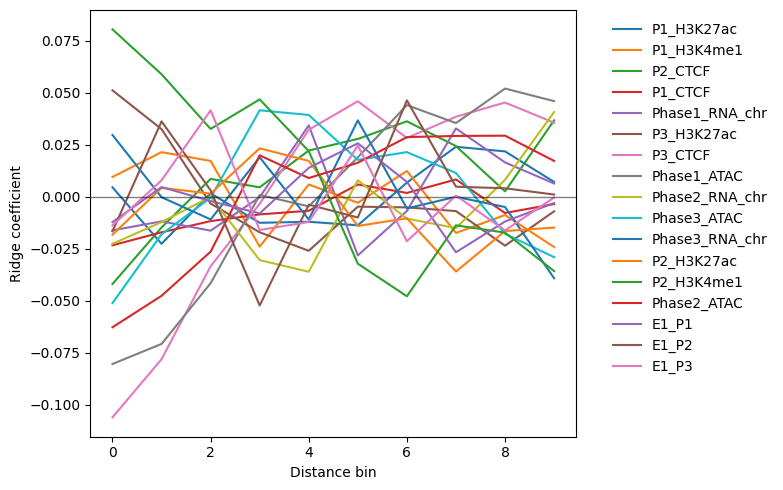

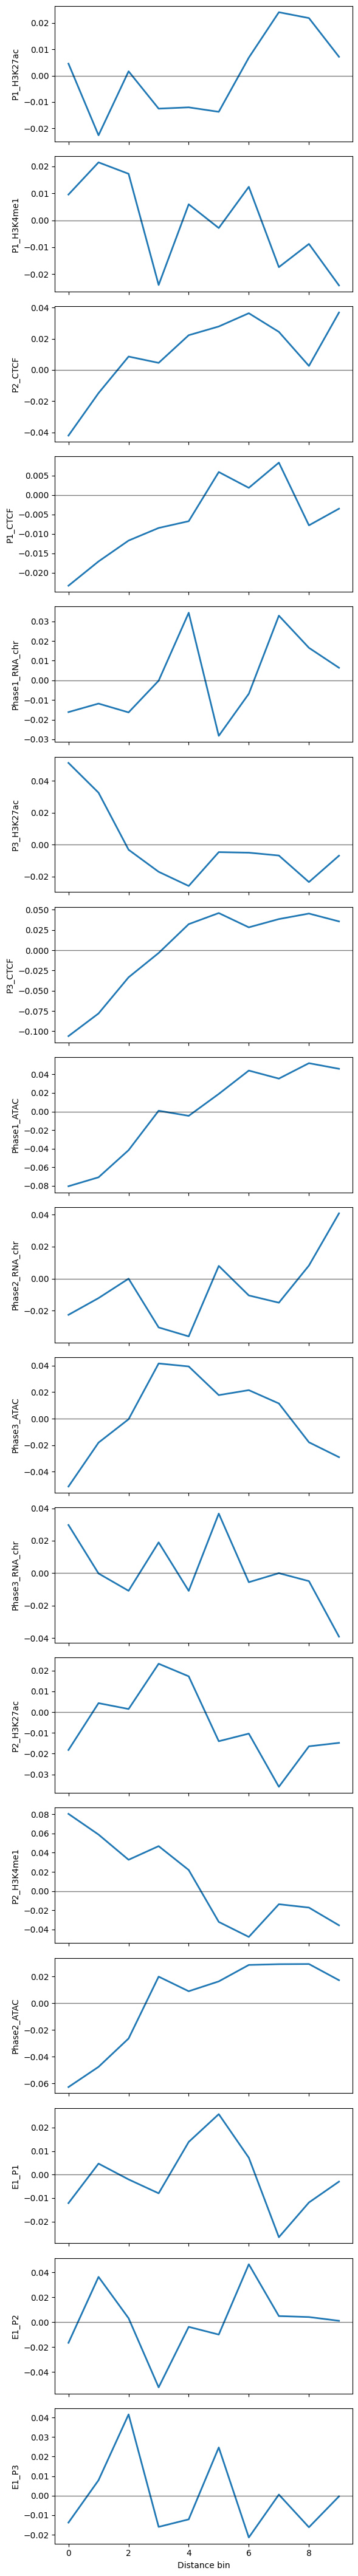

In [59]:
plot_coef_heatmap(reshaped, features, sd=os.path.join(savedir, "heatmap_color_equal.svg"))
plot_feature_distance_coefs(reshaped, features)
plot_per_feature_panels(reshaped, features, sd=None)

0.40617726945715793
0.4150554364054815
0.4251188851795059


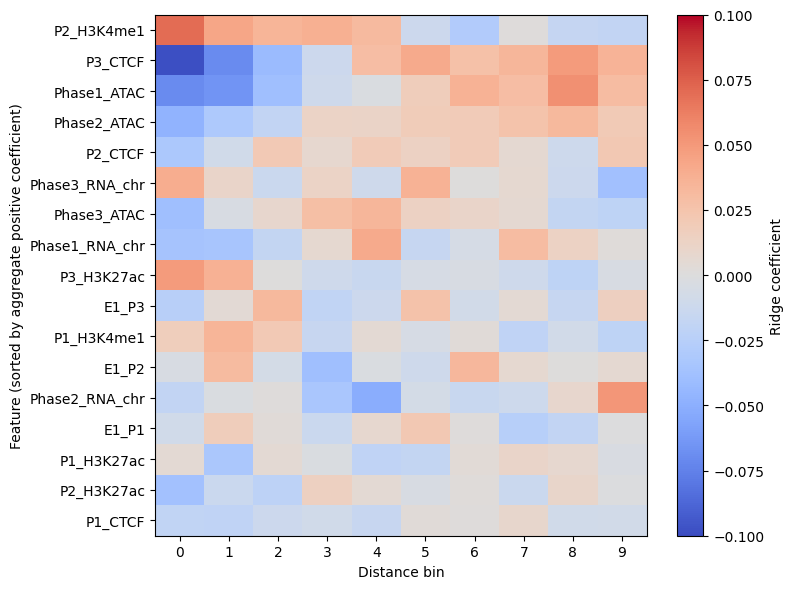

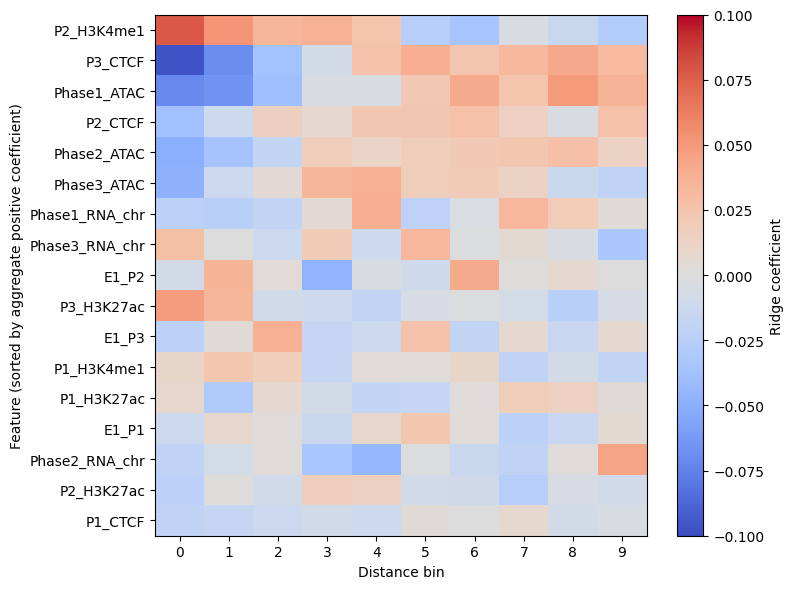

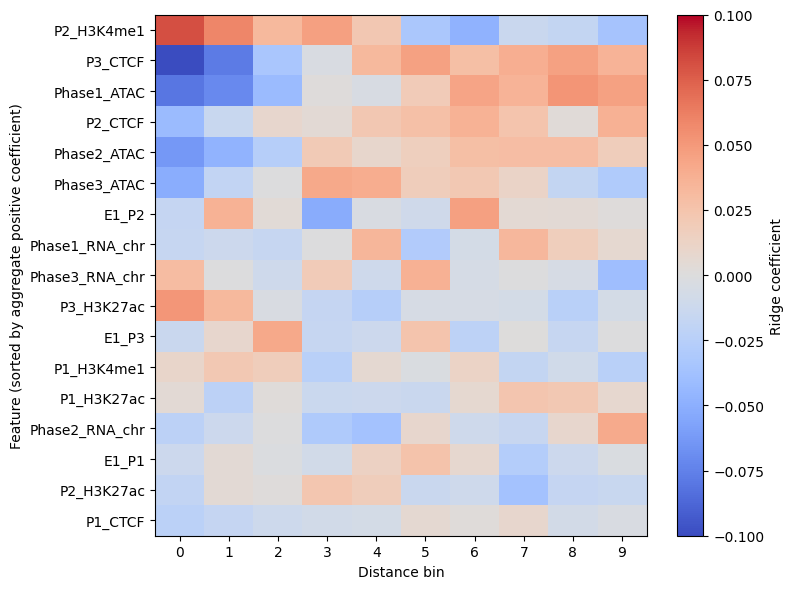

In [60]:
## now run on P1 and P3 for supplement
for phase in ['P1', 'P2', 'P3']:
    output = match_scores[f'triangle_score_{phase}'].values
    output[np.isnan(output)] = 0
    output[output==np.inf] = 0

    ridgePred = sklearn.linear_model.Ridge(alpha=alpha_use)
    fitted = ridgePred.fit(scaled_data, output)
    print(ridgePred.score(scaled_data, output))
    
    reshaped = reshape_ridge_coefs(ridgePred, len(features), np.shape(binned_inputs)[2])
    
    plot_coef_heatmap(reshaped, features, sd=os.path.join(supp_savedir, f"heatmap_reg_100_{phase}_equal.svg"))